In [40]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/notebooks/sowhardokabir/notebook0c97217c27/__results__.html
/kaggle/input/notebooks/sowhardokabir/notebook0c97217c27/__notebook__.ipynb
/kaggle/input/notebooks/sowhardokabir/notebook0c97217c27/__output__.json
/kaggle/input/notebooks/sowhardokabir/notebook0c97217c27/custom.css
/kaggle/input/notebooks/sowhardokabir/notebook0c97217c27/preprocessing_outputs/preprocessing_config.json
/kaggle/input/notebooks/sowhardokabir/notebook0c97217c27/preprocessing_outputs/train_split.csv
/kaggle/input/notebooks/sowhardokabir/notebook0c97217c27/preprocessing_outputs/test_split.csv
/kaggle/input/notebooks/sowhardokabir/notebook0c97217c27/preprocessing_outputs/internal_validation_split.csv
/kaggle/input/notebooks/sowhardokabir/notebook0c97217c27/preprocessing_outputs/class_names.json
/kaggle/input/notebooks/sowhardokabir/notebook0c97217c27/__results___files/__results___30_0.png
/kaggle/input/notebooks/sowhardokabir/notebook0c97217c27/__results___files/__results___29_0.png
/kaggle/input/data

# MaleVis Generalized CNN

This notebook develops a generalized CNN model for 25-class malware image classification using the cleaned MaleVis dataset.

The dataset splits were prepared beforehand:
- Training split for model learning
- Internal validation split for model selection and tuning
- Final test split for unbiased final evaluation

In [41]:
import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 1. Reproducibility

In [42]:
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seed:", SEED)

Random seed: 42


In [43]:
gpus = tf.config.list_physical_devices("GPU")

print("Available GPUs:", gpus)

if gpus:
    print("GPU is available.")
else:
    print("GPU not detected. Check Kaggle accelerator settings.")

Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
GPU is available.


## 2. Configuration

In [44]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)

BATCH_SIZE = 32
NUM_CLASSES = 25

INITIAL_LEARNING_RATE = 0.0005
MAX_EPOCHS = 30

AUTOTUNE = tf.data.AUTOTUNE

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Number of classes:", NUM_CLASSES)
print("Learning rate:", INITIAL_LEARNING_RATE)
print("Maximum epochs:", MAX_EPOCHS)

Image size: (224, 224)
Batch size: 32
Number of classes: 25
Learning rate: 0.0005
Maximum epochs: 30


In [45]:
for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if file in [
            "train_split.csv",
            "internal_validation_split.csv",
            "test_split.csv",
            "class_names.json",
            "preprocessing_config.json"
        ]:
            print(os.path.join(root, file))

/kaggle/input/notebooks/sowhardokabir/notebook0c97217c27/preprocessing_outputs/preprocessing_config.json
/kaggle/input/notebooks/sowhardokabir/notebook0c97217c27/preprocessing_outputs/train_split.csv
/kaggle/input/notebooks/sowhardokabir/notebook0c97217c27/preprocessing_outputs/test_split.csv
/kaggle/input/notebooks/sowhardokabir/notebook0c97217c27/preprocessing_outputs/internal_validation_split.csv
/kaggle/input/notebooks/sowhardokabir/notebook0c97217c27/preprocessing_outputs/class_names.json


In [46]:
png_folders = set()

for root, dirs, files in os.walk("/kaggle/input"):
    if any(
        file.lower().endswith(".png")
        for file in files
    ):
        png_folders.add(root)

for folder in sorted(png_folders):
    print(folder)

/kaggle/input/datasets/sohamkumar1703/malevis-dataset/malevis_train_val_300x300/train/Adposhel
/kaggle/input/datasets/sohamkumar1703/malevis-dataset/malevis_train_val_300x300/train/Agent
/kaggle/input/datasets/sohamkumar1703/malevis-dataset/malevis_train_val_300x300/train/Allaple
/kaggle/input/datasets/sohamkumar1703/malevis-dataset/malevis_train_val_300x300/train/Amonetize
/kaggle/input/datasets/sohamkumar1703/malevis-dataset/malevis_train_val_300x300/train/Androm
/kaggle/input/datasets/sohamkumar1703/malevis-dataset/malevis_train_val_300x300/train/Autorun
/kaggle/input/datasets/sohamkumar1703/malevis-dataset/malevis_train_val_300x300/train/BrowseFox
/kaggle/input/datasets/sohamkumar1703/malevis-dataset/malevis_train_val_300x300/train/Dinwod
/kaggle/input/datasets/sohamkumar1703/malevis-dataset/malevis_train_val_300x300/train/Elex
/kaggle/input/datasets/sohamkumar1703/malevis-dataset/malevis_train_val_300x300/train/Expiro
/kaggle/input/datasets/sohamkumar1703/malevis-dataset/malevis_t

In [47]:
PROCESSED_DIR = Path(
    "/kaggle/input/notebooks/sowhardokabir/notebook0c97217c27/preprocessing_outputs")

TRAIN_CSV = PROCESSED_DIR / "train_split.csv"
INTERNAL_VAL_CSV = PROCESSED_DIR / "internal_validation_split.csv"
TEST_CSV = PROCESSED_DIR / "test_split.csv"

CLASS_NAMES_FILE = PROCESSED_DIR / "class_names.json"
CONFIG_FILE = PROCESSED_DIR / "preprocessing_config.json"

In [48]:
required_files = [
    TRAIN_CSV,
    INTERNAL_VAL_CSV,
    TEST_CSV,
    CLASS_NAMES_FILE,
    CONFIG_FILE
]

for file_path in required_files:
    print(
        file_path.name,
        "->",
        "Found" if file_path.exists() else "Missing"
    )

assert all(
    file_path.exists()
    for file_path in required_files
)

print("All preprocessing files verified.")

train_split.csv -> Found
internal_validation_split.csv -> Found
test_split.csv -> Found
class_names.json -> Found
preprocessing_config.json -> Found
All preprocessing files verified.


## 3. Load Clean Dataset Splits

In [49]:
with open(CLASS_NAMES_FILE, "r") as file:
    class_names = json.load(file)

print("Number of classes:", len(class_names))
print(class_names)

assert len(class_names) == NUM_CLASSES

Number of classes: 25
['Adposhel', 'Agent', 'Allaple', 'Amonetize', 'Androm', 'Autorun', 'BrowseFox', 'Dinwod', 'Elex', 'Expiro', 'Fasong', 'HackKMS', 'Hlux', 'Injector', 'InstallCore', 'MultiPlug', 'Neoreklami', 'Neshta', 'Regrun', 'Sality', 'Snarasite', 'Stantinko', 'VBA', 'VBKrypt', 'Vilsel']


In [50]:
train_df = pd.read_csv(TRAIN_CSV)
internal_val_df = pd.read_csv(INTERNAL_VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

print("Training samples:", len(train_df))
print("Internal validation samples:", len(internal_val_df))
print("Final test samples:", len(test_df))

Training samples: 6999
Internal validation samples: 1751
Final test samples: 3477


In [51]:
display(train_df.head())
display(internal_val_df.head())
display(test_df.head())

,filepath,relative_path,class_name,label,label_id,hash
0,/kaggle/input/datasets/sohamkumar1703/malevis-...,train/Adposhel/490414f8e646fbad11d392106f38ec9...,Adposhel,Adposhel,0,5eabfcd800292738bcb70f818a8b9319
1,/kaggle/input/datasets/sohamkumar1703/malevis-...,train/Adposhel/96022ca14d5b070258c892ebf7153e0...,Adposhel,Adposhel,0,55951eca5fdd3aa764b096cba7e06ab9
2,/kaggle/input/datasets/sohamkumar1703/malevis-...,train/Adposhel/95c6546ecaf79394a4ace0512a52057...,Adposhel,Adposhel,0,bc1bd6f2cd6125334409930bba59d7a3
3,/kaggle/input/datasets/sohamkumar1703/malevis-...,train/Adposhel/774964c435f7b10f3227fceebfad605...,Adposhel,Adposhel,0,66ad26b2bd35d5017c54210bcc0e03e1
4,/kaggle/input/datasets/sohamkumar1703/malevis-...,train/Adposhel/91a0467c07dbb3282e07dc0a214846a...,Adposhel,Adposhel,0,c7baaebfdcf4ca3c1561105727feefb1


,filepath,relative_path,class_name,label,label_id,hash
0,/kaggle/input/datasets/sohamkumar1703/malevis-...,train/Adposhel/5e3b9cca64ff8f0eaad8f67c511e0a6...,Adposhel,Adposhel,0,03dbf87fc916a2a0dfd177ba9e330278
1,/kaggle/input/datasets/sohamkumar1703/malevis-...,train/Adposhel/87c470e98dffe5d9362b2e9f0650b59...,Adposhel,Adposhel,0,cf61cb8939737559fc14af9f20a501b5
2,/kaggle/input/datasets/sohamkumar1703/malevis-...,train/Adposhel/4749cda8f3cece89c9e2027d9f7ca6b...,Adposhel,Adposhel,0,e6b79ff658b56887275b14cc59a7c6b9
3,/kaggle/input/datasets/sohamkumar1703/malevis-...,train/Adposhel/0736917e1208c27a9cd529e8fa3d9eb...,Adposhel,Adposhel,0,60fa977472b0a0bdcaf678d255c67f65
4,/kaggle/input/datasets/sohamkumar1703/malevis-...,train/Adposhel/134f26d244c263ff87f6d51cbb923a8...,Adposhel,Adposhel,0,809c9ea5c1be9fb12f8db75ce93d9b1b


,filepath,relative_path,class_name,label,label_id,hash
0,/kaggle/input/datasets/sohamkumar1703/malevis-...,val/Adposhel/fca5de1a353db8f6e9419a7eff62a97a2...,Adposhel,Adposhel,0,974ced03c9ed9989d449c80121f0c760
1,/kaggle/input/datasets/sohamkumar1703/malevis-...,val/Adposhel/d689f28a776829343d313486a8051978c...,Adposhel,Adposhel,0,adb08e8813ac62f68f3f74ab6fcaf8aa
2,/kaggle/input/datasets/sohamkumar1703/malevis-...,val/Adposhel/beca37575577184d704d450bb51661fd8...,Adposhel,Adposhel,0,bbd2f4d41402f4fc854513719a6b0cb9
3,/kaggle/input/datasets/sohamkumar1703/malevis-...,val/Adposhel/fcbe2516d817437f619a9c124c3210932...,Adposhel,Adposhel,0,f2b60393e5dd60456f9fa15d657b1611
4,/kaggle/input/datasets/sohamkumar1703/malevis-...,val/Adposhel/e97f1ef855a76027289ded7c9fe923239...,Adposhel,Adposhel,0,a0bdcfe313a98e7df3434a20de07e0fc


# Dataset Verfication

In [52]:
required_columns = {
    "filepath",
    "relative_path",
    "class_name",
    "label_id",
    "hash"
}

for split_name, dataframe in [
    ("Train", train_df),
    ("Internal Validation", internal_val_df),
    ("Test", test_df)
]:
    missing = required_columns - set(dataframe.columns)

    print(split_name, "missing columns:", missing)

    assert len(missing) == 0

print("Required columns verified.")

Train missing columns: set()
Internal Validation missing columns: set()
Test missing columns: set()
Required columns verified.


In [53]:
for dataframe in [
    train_df,
    internal_val_df,
    test_df
]:
    dataframe["label_id"] = dataframe["label_id"].astype(np.int32)

In [54]:
for split_name, dataframe in [
    ("Train", train_df),
    ("Internal Validation", internal_val_df),
    ("Test", test_df)
]:
    print(
        split_name,
        "classes:",
        dataframe["label_id"].nunique()
    )

    assert dataframe["label_id"].nunique() == NUM_CLASSES

print("All three splits contain 25 classes.")

Train classes: 25
Internal Validation classes: 25
Test classes: 25
All three splits contain 25 classes.


In [55]:
train_hashes = set(train_df["hash"].astype(str))
val_hashes = set(internal_val_df["hash"].astype(str))
test_hashes = set(test_df["hash"].astype(str))

print(
    "Train vs Validation overlap:",
    len(train_hashes & val_hashes)
)

print(
    "Train vs Test overlap:",
    len(train_hashes & test_hashes)
)

print(
    "Validation vs Test overlap:",
    len(val_hashes & test_hashes)
)

assert len(train_hashes & val_hashes) == 0
assert len(train_hashes & test_hashes) == 0
assert len(val_hashes & test_hashes) == 0

print("No cross-split hash leakage.")

Train vs Validation overlap: 0
Train vs Test overlap: 0
Validation vs Test overlap: 0
No cross-split hash leakage.


## 4. Rebuild Image Paths

In [56]:
DATASET_DIR = Path(
    "/kaggle/input/datasets/sohamkumar1703/"
    "malevis-dataset/malevis_train_val_300x300"
)

print("Dataset directory:", DATASET_DIR)
print("Exists:", DATASET_DIR.exists())

Dataset directory: /kaggle/input/datasets/sohamkumar1703/malevis-dataset/malevis_train_val_300x300
Exists: True


In [57]:
def resolve_image_path(relative_path):
    relative_path = str(relative_path).replace("\\", "/")
    relative_path = relative_path.lstrip("/")

    possible_paths = [
        DATASET_DIR / relative_path,
        DATASET_DIR / "train" / relative_path,
        DATASET_DIR / "val" / relative_path,
    ]

    for path in possible_paths:
        if path.exists():
            return str(path)

    return None

In [58]:
train_df["current_filepath"] = (
    train_df["relative_path"].apply(resolve_image_path)
)

internal_val_df["current_filepath"] = (
    internal_val_df["relative_path"].apply(resolve_image_path)
)

test_df["current_filepath"] = (
    test_df["relative_path"].apply(resolve_image_path)
)

In [59]:
for split_name, dataframe in [
    ("Train", train_df),
    ("Internal Validation", internal_val_df),
    ("Test", test_df)
]:
    missing = dataframe["current_filepath"].isnull().sum()

    print(split_name, "missing paths:", missing)

    assert missing == 0

print("All image paths resolved successfully.")

Train missing paths: 0
Internal Validation missing paths: 0
Test missing paths: 0
All image paths resolved successfully.


## 5. Class Distribution

In [60]:
train_distribution = (
    train_df
    .groupby(["label_id", "class_name"])
    .size()
    .reset_index(name="image_count")
    .sort_values("label_id")
)

display(train_distribution)

,label_id,class_name,image_count
0,0,Adposhel,280
1,1,Agent,280
2,2,Allaple,280
3,3,Amonetize,281
4,4,Androm,280
5,5,Autorun,280
6,6,BrowseFox,280
7,7,Dinwod,280
8,8,Elex,280
9,9,Expiro,280


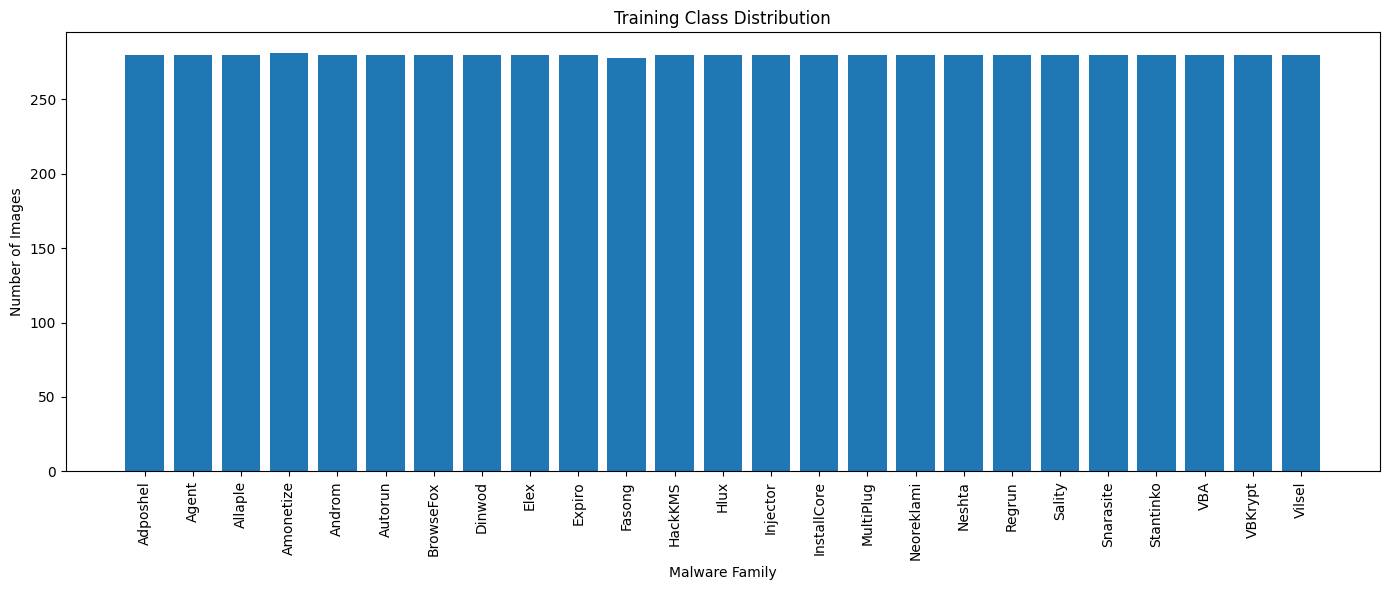

In [61]:
plt.figure(figsize=(14, 6))

plt.bar(
    train_distribution["class_name"],
    train_distribution["image_count"]
)

plt.title("Training Class Distribution")
plt.xlabel("Malware Family")
plt.ylabel("Number of Images")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

## 6. TensorFlow Data Pipeline

In [62]:
def load_and_normalize_image(image_path, label):
    image = tf.io.read_file(image_path)

    image = tf.image.decode_png(
        image,
        channels=3
    )

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    )

    image = image / 255.0

    return image, label

In [63]:
 data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomRotation(
            factor=0.02
        ),

        tf.keras.layers.RandomZoom(
            height_factor=0.03,
            width_factor=0.03
        ),

        tf.keras.layers.RandomTranslation(
            height_factor=0.02,
            width_factor=0.02
        ),
    ],
    name="training_augmentation"
)

print("Mild training augmentation created.")

Mild training augmentation created.


I0000 00:00:1786996296.080863      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786996296.083956      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [64]:
train_paths = (
    train_df["current_filepath"]
    .astype(str)
    .to_numpy()
)

train_labels = (
    train_df["label_id"]
    .astype(np.int32)
    .to_numpy()
)

internal_val_paths = (
    internal_val_df["current_filepath"]
    .astype(str)
    .to_numpy()
)

internal_val_labels = (
    internal_val_df["label_id"]
    .astype(np.int32)
    .to_numpy()
)

test_paths = (
    test_df["current_filepath"]
    .astype(str)
    .to_numpy()
)

test_labels = (
    test_df["label_id"]
    .astype(np.int32)
    .to_numpy()
)

print("Train:", train_paths.shape, train_labels.shape)
print(
    "Internal validation:",
    internal_val_paths.shape,
    internal_val_labels.shape
)
print("Test:", test_paths.shape, test_labels.shape)

Train: (6999,) (6999,)
Internal validation: (1751,) (1751,)
Test: (3477,) (3477,)


In [65]:
def create_dataset(
    image_paths,
    labels,
    training=False
):
    dataset = tf.data.Dataset.from_tensor_slices(
        (
            image_paths,
            labels
        )
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(image_paths),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_and_normalize_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(
        BATCH_SIZE
    )

    if training:
        dataset = dataset.map(
            lambda images, batch_labels: (
                data_augmentation(
                    images,
                    training=True
                ),
                batch_labels
            ),
            num_parallel_calls=AUTOTUNE
        )

    dataset = dataset.prefetch(
        AUTOTUNE
    )

    return dataset

In [66]:
 train_ds = create_dataset(
    train_paths,
    train_labels,
    training=True
)

internal_val_ds = create_dataset(
    internal_val_paths,
    internal_val_labels,
    training=False
)

test_ds = create_dataset(
    test_paths,
    test_labels,
    training=False
)

print("Datasets recreated successfully.")

Datasets recreated successfully.


In [67]:
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Image dtype:", images.dtype)
    print(
        "Pixel min:",
        float(tf.reduce_min(images))
    )
    print(
        "Pixel max:",
        float(tf.reduce_max(images))
    )

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Image dtype: <dtype: 'float32'>
Pixel min: 0.0
Pixel max: 0.999931812286377


In [68]:
for split_name, dataset in [
    ("Internal Validation", internal_val_ds),
    ("Test", test_ds)
]:
    for images, labels in dataset.take(1):
        print(
            split_name,
            "image shape:",
            images.shape
        )

        print(
            split_name,
            "label shape:",
            labels.shape
        )

Internal Validation image shape: (32, 224, 224, 3)
Internal Validation label shape: (32,)
Test image shape: (32, 224, 224, 3)
Test label shape: (32,)


## 7. Data Visualization

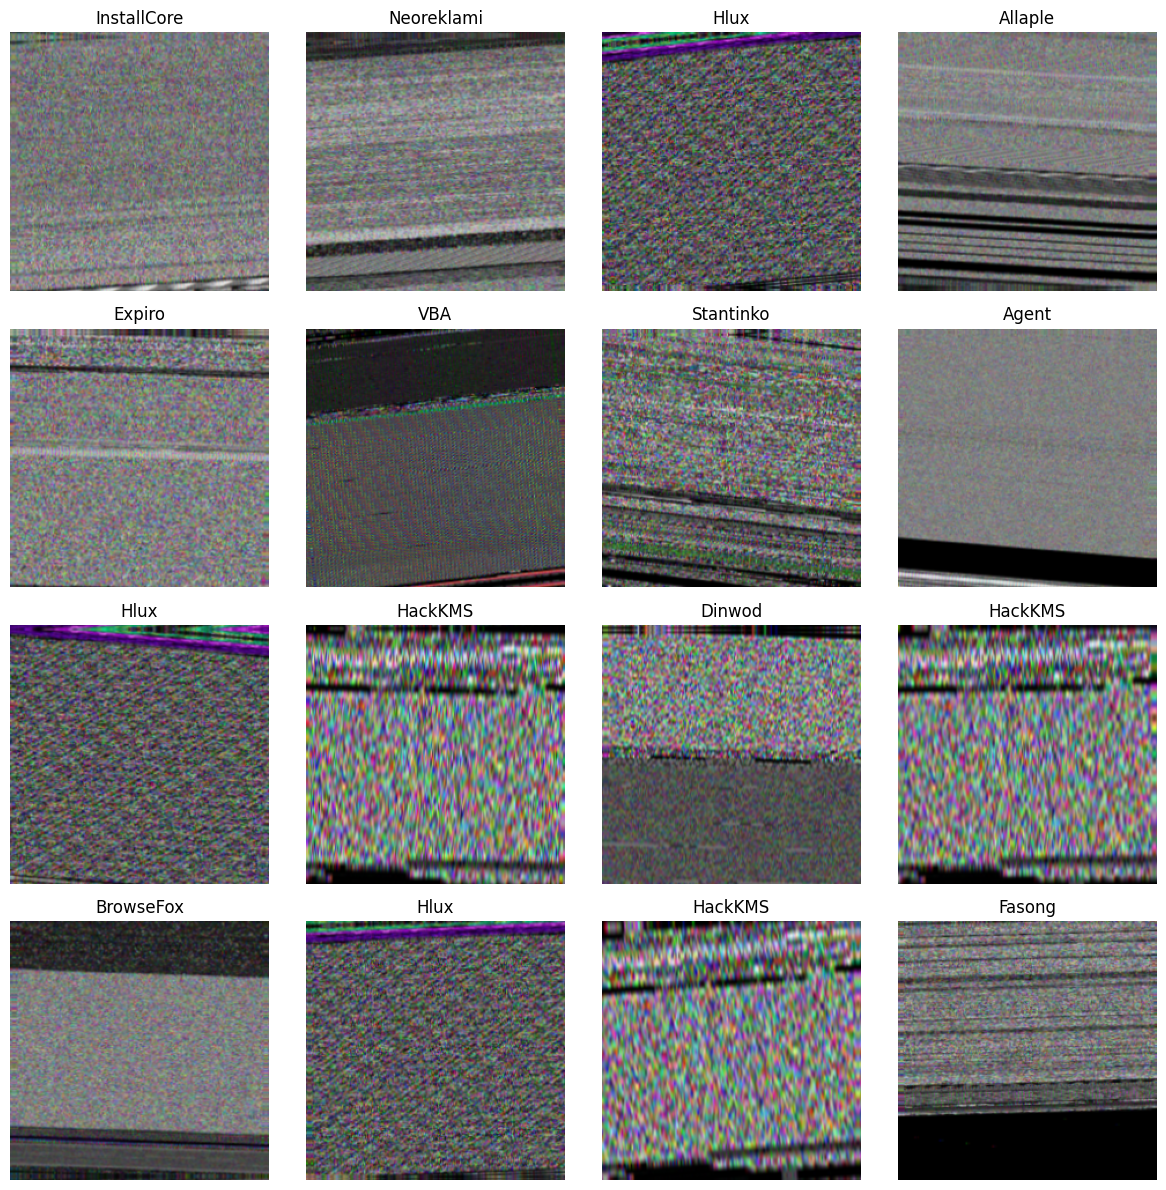

In [69]:
plt.figure(figsize=(12, 12))

for images, labels in train_ds.take(1):
    for index in range(16):
        plt.subplot(
            4,
            4,
            index + 1
        )

        plt.imshow(
            images[index].numpy()
        )

        label_id = int(
            labels[index].numpy()
        )

        plt.title(
            class_names[label_id]
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

 ## 8. Generalization-Focused CNN Model

The CNN uses moderate model capacity with controlled regularization.
The objective is to learn sufficiently rich malware-image features
while reducing excessive memorization of the training data.

In [70]:
 from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras import Model

tf.keras.backend.clear_session()

L2_WEIGHT = 1e-5

inputs = layers.Input(
    shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    name="input_image"
)

# Block 1
x = layers.Conv2D(
    32,
    3,
    padding="same",
    use_bias=False,
    kernel_regularizer=regularizers.l2(L2_WEIGHT)
)(inputs)

x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.MaxPooling2D(2)(x)


# Block 2
x = layers.Conv2D(
    64,
    3,
    padding="same",
    use_bias=False,
    kernel_regularizer=regularizers.l2(L2_WEIGHT)
)(x)

x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.MaxPooling2D(2)(x)


# Block 3
x = layers.Conv2D(
    128,
    3,
    padding="same",
    use_bias=False,
    kernel_regularizer=regularizers.l2(L2_WEIGHT)
)(x)

x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.MaxPooling2D(2)(x)


# Block 4
x = layers.Conv2D(
    256,
    3,
    padding="same",
    use_bias=False,
    kernel_regularizer=regularizers.l2(L2_WEIGHT)
)(x)

x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.MaxPooling2D(2)(x)


# Classification head
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(
    128,
    activation="relu",
    kernel_regularizer=regularizers.l2(L2_WEIGHT)
)(x)

x = layers.BatchNormalization()(x)

x = layers.Dropout(
    0.40
)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="predictions"
)(x)

model = Model(
    inputs=inputs,
    outputs=outputs,
    name="malevis_generalized_cnn"
)

print("Generalization-focused CNN created.")

Generalization-focused CNN created.


In [71]:
model.summary()

Model: "malevis_generalized_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 25)             │         3,22

 Total params: 426,489 (1.63 MB)

 Trainable params: 425,273 (1.62 MB)

 Non-trainable params: 1,216 (4.75 KB)

## 9. Model Compilation

In [72]:
  INITIAL_LEARNING_RATE = 0.0005

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=INITIAL_LEARNING_RATE
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [73]:
 OUTPUT_DIR = Path(
    "/kaggle/working/generalized_cnn_v3_outputs"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

BEST_MODEL_PATH = (
    OUTPUT_DIR /
    "best_generalized_cnn.keras"
)

TRAINING_LOG_PATH = (
    OUTPUT_DIR /
    "training_log.csv"
)

## 10. Training Callbacks

In [74]:
 callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(BEST_MODEL_PATH),
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),

    tf.keras.callbacks.CSVLogger(
        filename=str(TRAINING_LOG_PATH)
    ),

    tf.keras.callbacks.TerminateOnNaN()
]

print("Callbacks configured.")

Callbacks configured.


In [75]:
 print("=" * 45)
print("Generalized CNN Configuration")
print("=" * 45)

print("Model             :", model.name)
print("Image size        :", IMG_SIZE)
print("Classes           :", NUM_CLASSES)
print("Batch size        :", BATCH_SIZE)
print("Initial LR        :", INITIAL_LEARNING_RATE)
print("Maximum epochs    :", MAX_EPOCHS)
print("L2 weight         :", L2_WEIGHT)
print("Dense dropout     :", 0.35)

print("=" * 45)

Generalized CNN Configuration
Model             : malevis_generalized_cnn
Image size        : (224, 224)
Classes           : 25
Batch size        : 32
Initial LR        : 0.0005
Maximum epochs    : 30
L2 weight         : 1e-05
Dense dropout     : 0.35


## 11. Model Training

In [76]:
 history = model.fit(
    train_ds,
    validation_data=internal_val_ds,
    epochs=MAX_EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
  2/219 ━━━━━━━━━━━━━━━━━━━━ 19s 88ms/step - accuracy: 0.0703 - loss: 3.8573 

I0000 00:00:1786996315.901057     191 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.3714 - loss: 2.3589
Epoch 1: val_loss improved from None to 4.19310, saving model to /kaggle/working/generalized_cnn_v3_outputs/best_generalized_cnn.keras

Epoch 1: finished saving model to /kaggle/working/generalized_cnn_v3_outputs/best_generalized_cnn.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 78s 299ms/step - accuracy: 0.5094 - loss: 1.8745 - val_accuracy: 0.0480 - val_loss: 4.1931 - learning_rate: 5.0000e-04
Epoch 2/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.6778 - loss: 1.2371
Epoch 2: val_loss improved from 4.19310 to 2.34938, saving model to /kaggle/working/generalized_cnn_v3_outputs/best_generalized_cnn.keras

Epoch 2: finished saving model to /kaggle/working/generalized_cnn_v3_outputs/best_generalized_cnn.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 45s 202ms/step - accuracy: 0.7145 - loss: 1.1134 - val_accuracy: 0.4021 - val_loss: 2.3494 - learning_rate: 5.0000e-04
Epoch 3/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - 

In [77]:
print("Checking internal validation stability...\n")

results = []

for i in range(5):
    val_loss, val_acc = model.evaluate(
        internal_val_ds,
        verbose=0
    )

    results.append((val_loss, val_acc))

    print(
        f"Run {i+1}: "
        f"val_loss = {val_loss:.4f}, "
        f"val_accuracy = {val_acc:.4f}"
    )

Checking internal validation stability...

Run 1: val_loss = 0.7940, val_accuracy = 0.7733
Run 2: val_loss = 0.7940, val_accuracy = 0.7733
Run 3: val_loss = 0.7940, val_accuracy = 0.7733
Run 4: val_loss = 0.7940, val_accuracy = 0.7733
Run 5: val_loss = 0.7940, val_accuracy = 0.7733


In [78]:
import numpy as np

val_losses = [x[0] for x in results]
val_accuracies = [x[1] for x in results]

print("\nValidation stability summary")
print("-" * 35)

print(
    "Mean validation accuracy:",
    np.mean(val_accuracies)
)

print(
    "Accuracy std:",
    np.std(val_accuracies)
)

print(
    "Mean validation loss:",
    np.mean(val_losses)
)

print(
    "Loss std:",
    np.std(val_losses)
)


Validation stability summary
-----------------------------------
Mean validation accuracy: 0.7732723951339722
Accuracy std: 0.0
Mean validation loss: 0.7940296530723572
Loss std: 0.0


In [79]:
best_model = tf.keras.models.load_model(
    BEST_MODEL_PATH
)

print("Best generalized CNN loaded.")

Best generalized CNN loaded.


In [80]:
val_loss, val_accuracy = best_model.evaluate(
    internal_val_ds,
    verbose=1
)

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.7733 - loss: 0.7940
Validation Loss: 0.7940
Validation Accuracy: 77.33%


In [81]:
test_loss, test_accuracy = best_model.evaluate(
    test_ds,
    verbose=1
)

print(f"Final Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")

109/109 ━━━━━━━━━━━━━━━━━━━━ 12s 114ms/step - accuracy: 0.7725 - loss: 0.7762
Final Test Loss: 0.7762
Final Test Accuracy: 77.25%


## 12. Test Predictions

In [82]:
y_true = []
y_pred = []
y_prob = []

for images, labels in test_ds:
    probabilities = best_model.predict(
        images,
        verbose=0
    )

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predictions)
    y_prob.extend(probabilities)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

print("Test predictions completed.")
print("Samples:", len(y_true))

Test predictions completed.
Samples: 3477


In [83]:
calculated_accuracy = accuracy_score(
    y_true,
    y_pred
)

print(
    f"Calculated test accuracy: "
    f"{calculated_accuracy * 100:.2f}%"
)

print(
    f"Model.evaluate test accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

Calculated test accuracy: 77.25%
Model.evaluate test accuracy: 77.25%


## 13. Classification Report

In [84]:
 report_text = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print(report_text)

              precision    recall  f1-score   support

    Adposhel     0.9730    1.0000    0.9863       144
       Agent     0.4058    0.4667    0.4341       120
     Allaple     0.6788    0.7266    0.7019       128
   Amonetize     1.0000    0.7938    0.8851        97
      Androm     0.8882    0.9533    0.9196       150
     Autorun     0.9559    0.4452    0.6075       146
   BrowseFox     0.6784    0.9441    0.7895       143
      Dinwod     0.9338    0.9463    0.9400       149
        Elex     1.0000    0.3800    0.5507       150
      Expiro     0.5089    0.5695    0.5375       151
      Fasong     1.0000    1.0000    1.0000        33
     HackKMS     0.9858    0.9329    0.9586       149
        Hlux     1.0000    0.0733    0.1366       150
    Injector     0.9115    0.7103    0.7984       145
 InstallCore     1.0000    0.9467    0.9726       150
   MultiPlug     0.8030    0.7114    0.7544       149
  Neoreklami     1.0000    0.7667    0.8679       150
      Neshta     0.5068    

In [85]:
precision, recall, f1_score, _ = (
    precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )
)

print(
    f"Weighted Precision: "
    f"{precision * 100:.2f}%"
)

print(
    f"Weighted Recall: "
    f"{recall * 100:.2f}%"
)

print(
    f"Weighted F1-score: "
    f"{f1_score * 100:.2f}%"
)

Weighted Precision: 82.83%
Weighted Recall: 77.25%
Weighted F1-score: 76.56%


In [86]:
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = (
    pd.DataFrame(report_dict)
    .transpose()
)

REPORT_PATH = (
    OUTPUT_DIR /
    "classification_report.csv"
)

report_df.to_csv(
    REPORT_PATH
)

display(report_df)

print(
    "Classification report saved:",
    REPORT_PATH
)

,precision,recall,f1-score,support
Adposhel,0.972973,1.000000,0.986301,144.000000
Agent,0.405797,0.466667,0.434109,120.000000
Allaple,0.678832,0.726562,0.701887,128.000000
Amonetize,1.000000,0.793814,0.885057,97.000000
Androm,0.888199,0.953333,0.919614,150.000000
Autorun,0.955882,0.445205,0.607477,146.000000
BrowseFox,0.678392,0.944056,0.789474,143.000000
Dinwod,0.933775,0.946309,0.940000,149.000000
Elex,1.000000,0.380000,0.550725,150.000000
Expiro,0.508876,0.569536,0.537500,151.000000


Classification report saved: /kaggle/working/generalized_cnn_v3_outputs/classification_report.csv


## 14. Confusion Matrix

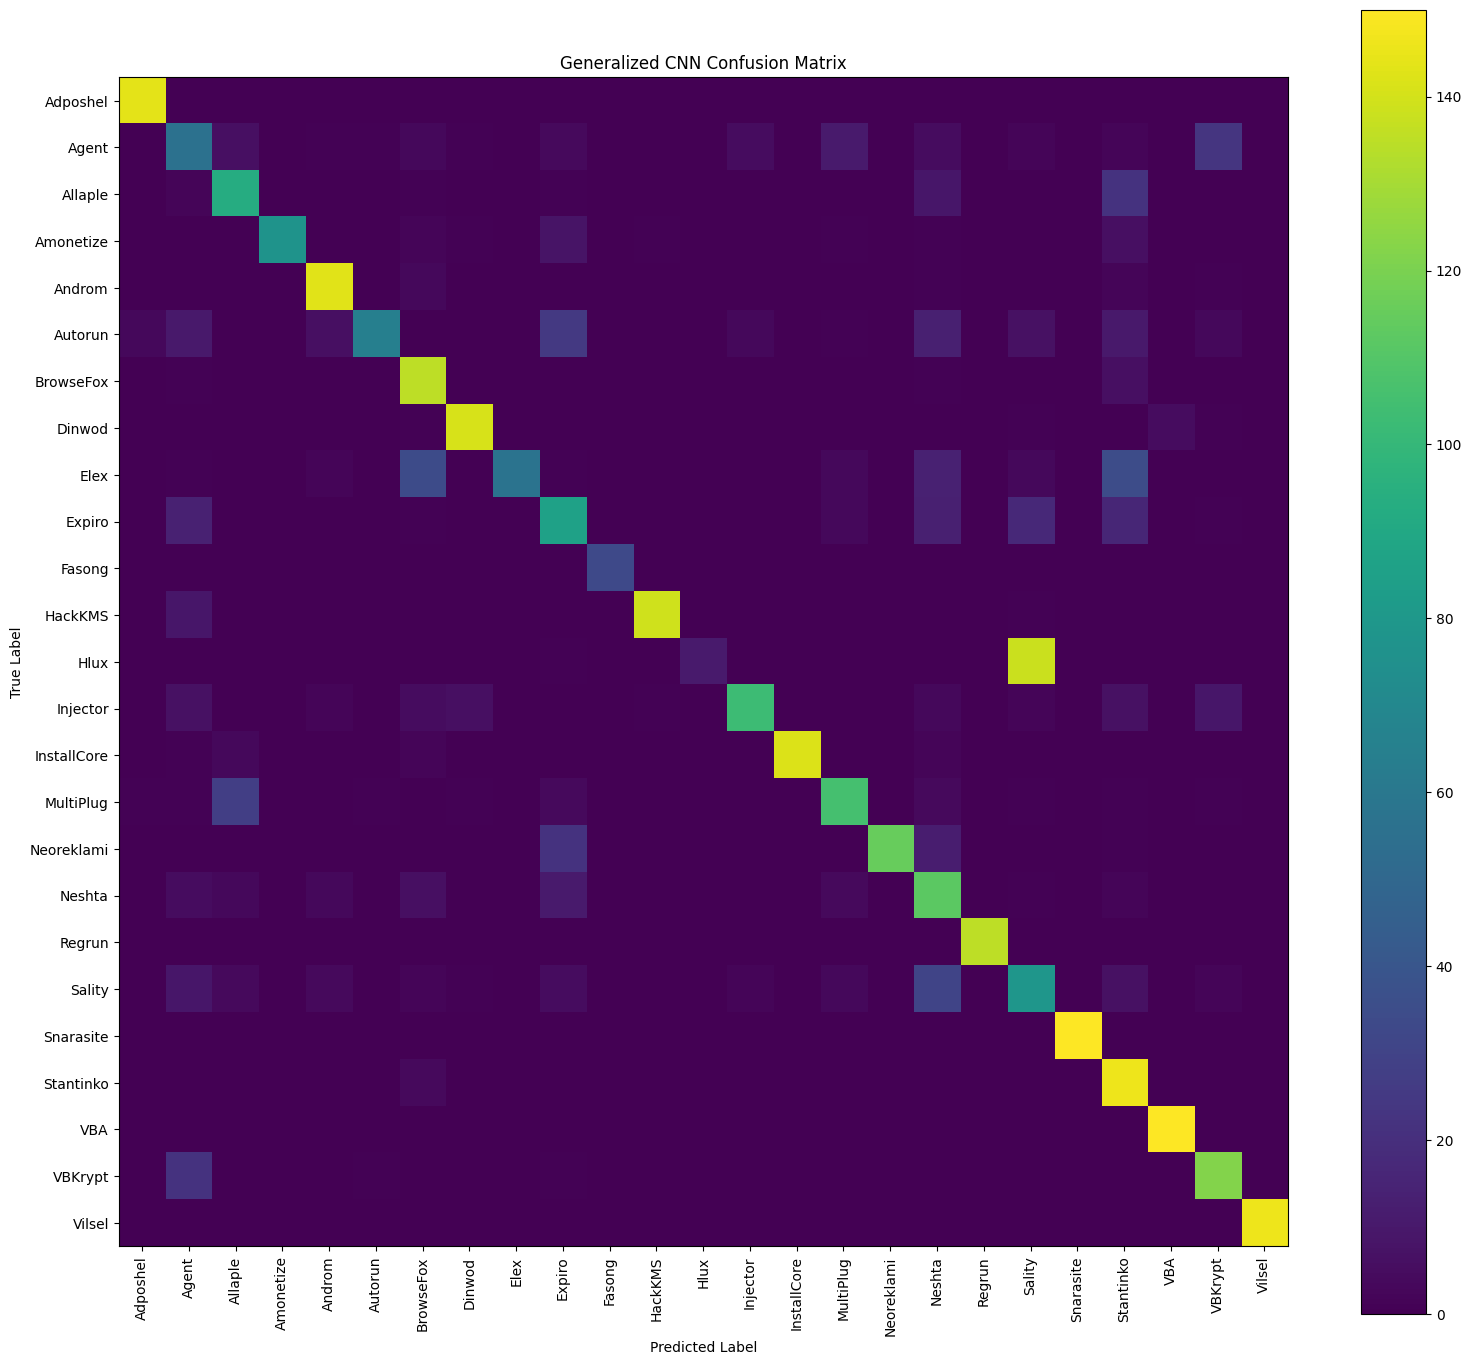

In [87]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(
    figsize=(16, 14)
)

plt.imshow(
    cm,
    interpolation="nearest"
)

plt.title(
    "Generalized CNN Confusion Matrix"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "True Label"
)

plt.colorbar()

plt.xticks(
    range(NUM_CLASSES),
    class_names,
    rotation=90
)

plt.yticks(
    range(NUM_CLASSES),
    class_names
)

plt.tight_layout()

CONFUSION_MATRIX_PATH = (
    OUTPUT_DIR /
    "confusion_matrix.png"
)

plt.savefig(
    CONFUSION_MATRIX_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

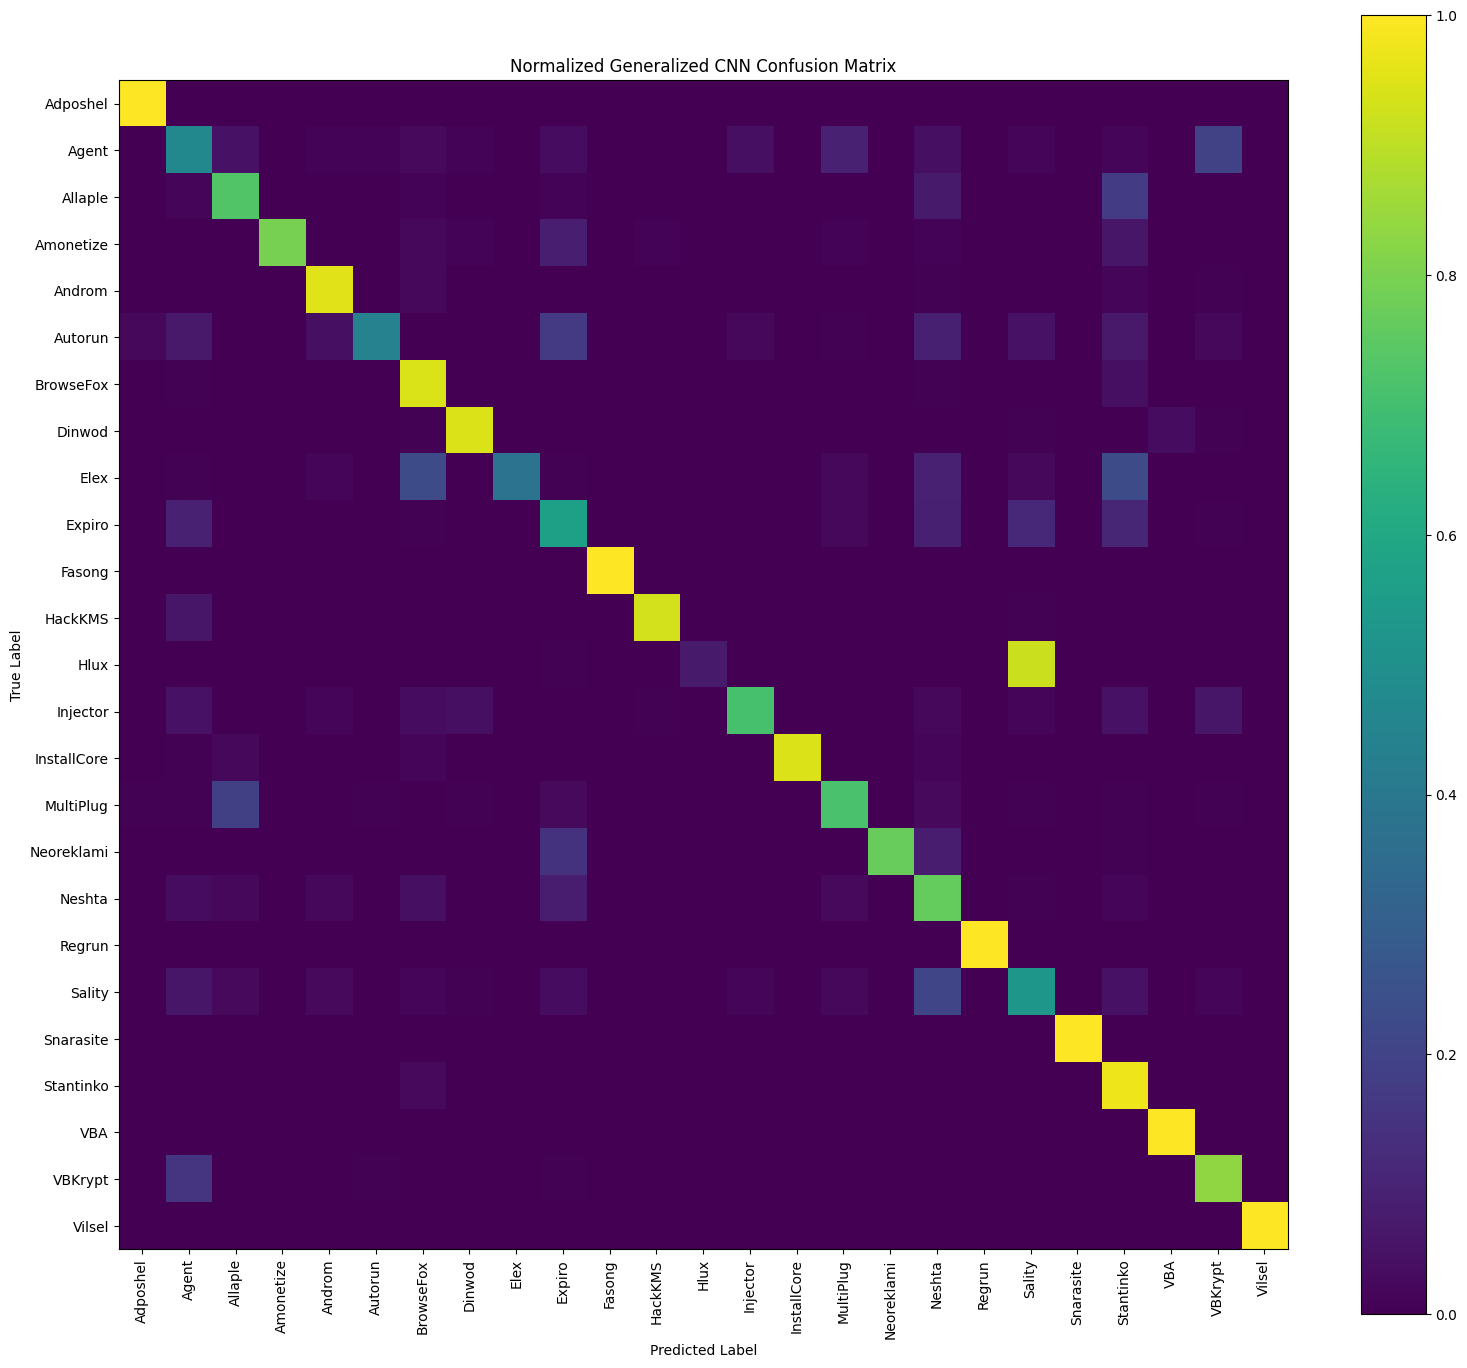

In [88]:
cm_normalized = (
    cm.astype("float") /
    cm.sum(axis=1)[:, np.newaxis]
)

plt.figure(
    figsize=(16, 14)
)

plt.imshow(
    cm_normalized,
    interpolation="nearest",
    vmin=0,
    vmax=1
)

plt.title(
    "Normalized Generalized CNN Confusion Matrix"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "True Label"
)

plt.colorbar()

plt.xticks(
    range(NUM_CLASSES),
    class_names,
    rotation=90
)

plt.yticks(
    range(NUM_CLASSES),
    class_names
)

plt.tight_layout()

NORMALIZED_CM_PATH = (
    OUTPUT_DIR /
    "normalized_confusion_matrix.png"
)

plt.savefig(
    NORMALIZED_CM_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [89]:
class_performance = report_df.loc[
    class_names,
    [
        "precision",
        "recall",
        "f1-score",
        "support"
    ]
].copy()

class_performance = (
    class_performance
    .sort_values(
        "f1-score",
        ascending=False
    )
)

display(class_performance)

,precision,recall,f1-score,support
Fasong,1.000000,1.000000,1.000000,33.0
Regrun,1.000000,1.000000,1.000000,135.0
Snarasite,1.000000,1.000000,1.000000,150.0
Vilsel,1.000000,1.000000,1.000000,146.0
Adposhel,0.972973,1.000000,0.986301,144.0
VBA,0.967742,1.000000,0.983607,150.0
InstallCore,1.000000,0.946667,0.972603,150.0
HackKMS,0.985816,0.932886,0.958621,149.0
Dinwod,0.933775,0.946309,0.940000,149.0
Androm,0.888199,0.953333,0.919614,150.0


In [90]:
CLASS_PERFORMANCE_PATH = (
    OUTPUT_DIR /
    "class_performance.csv"
)

class_performance.to_csv(
    CLASS_PERFORMANCE_PATH
)

print(
    "Class performance saved:",
    CLASS_PERFORMANCE_PATH
)

Class performance saved: /kaggle/working/generalized_cnn_v3_outputs/class_performance.csv


In [91]:
prediction_df = test_df[
    [
        "relative_path",
        "class_name",
        "label_id"
    ]
].copy()

prediction_df["predicted_label_id"] = y_pred

prediction_df["predicted_class"] = [
    class_names[index]
    for index in y_pred
]

prediction_df["correct"] = (
    prediction_df["label_id"]
    ==
    prediction_df["predicted_label_id"]
)

prediction_df[
    "prediction_confidence"
] = np.max(
    y_prob,
    axis=1
)

PREDICTIONS_PATH = (
    OUTPUT_DIR /
    "test_predictions.csv"
)

prediction_df.to_csv(
    PREDICTIONS_PATH,
    index=False
)

print(
    "Predictions saved:",
    PREDICTIONS_PATH
)

print(
    "Correct predictions:",
    prediction_df["correct"].sum()
)

print(
    "Incorrect predictions:",
    (~prediction_df["correct"]).sum()
)

Predictions saved: /kaggle/working/generalized_cnn_v3_outputs/test_predictions.csv
Correct predictions: 2686
Incorrect predictions: 791


In [92]:
final_metrics = {
    "model_name": "MaleVis Generalized CNN",
    "best_validation_accuracy": float(
        val_accuracy
    ),
    "best_validation_loss": float(
        val_loss
    ),
    "final_test_accuracy": float(
        test_accuracy
    ),
    "final_test_loss": float(
        test_loss
    ),
    "weighted_precision": float(
        precision
    ),
    "weighted_recall": float(
        recall
    ),
    "weighted_f1_score": float(
        f1_score
    ),
    "number_of_classes": int(
        NUM_CLASSES
    ),
    "training_samples": int(
        len(train_df)
    ),
    "validation_samples": int(
        len(internal_val_df)
    ),
    "test_samples": int(
        len(test_df)
    )
}

METRICS_PATH = (
    OUTPUT_DIR /
    "final_metrics.json"
)

with open(
    METRICS_PATH,
    "w"
) as file:
    json.dump(
        final_metrics,
        file,
        indent=4
    )

print(
    "Final metrics saved:",
    METRICS_PATH
)

Final metrics saved: /kaggle/working/generalized_cnn_v3_outputs/final_metrics.json


In [93]:
FINAL_MODEL_PATH = (
    OUTPUT_DIR /
    "malevis_generalized_cnn_final.keras"
)

best_model.save(
    FINAL_MODEL_PATH
)

print(
    "Final model saved:",
    FINAL_MODEL_PATH
)

Final model saved: /kaggle/working/generalized_cnn_v3_outputs/malevis_generalized_cnn_final.keras


In [94]:
print("Generated files:")

for file_path in sorted(
    OUTPUT_DIR.iterdir()
):
    print(
        "-",
        file_path.name
    )

Generated files:
- best_generalized_cnn.keras
- class_performance.csv
- classification_report.csv
- confusion_matrix.png
- final_metrics.json
- malevis_generalized_cnn_final.keras
- normalized_confusion_matrix.png
- test_predictions.csv
- training_log.csv


## 15. Final Results Summary

The final generalized CNN was evaluated on the internal validation
and untouched final test sets.

The final model achieved stable validation and test performance,
indicating improved generalization compared with its training
performance.

The test set was used only after model selection and tuning were
completed.

In [95]:
print("=" * 45)
print("Final Generalized CNN Results")
print("=" * 45)

print(f"Validation Accuracy : {val_accuracy * 100:.2f}%")
print(f"Validation Loss     : {val_loss:.4f}")

print(f"Test Accuracy       : {test_accuracy * 100:.2f}%")
print(f"Test Loss           : {test_loss:.4f}")

print(f"Weighted Precision  : {precision * 100:.2f}%")
print(f"Weighted Recall     : {recall * 100:.2f}%")
print(f"Weighted F1-score   : {f1_score * 100:.2f}%")

print("=" * 45)

Final Generalized CNN Results
Validation Accuracy : 77.33%
Validation Loss     : 0.7940
Test Accuracy       : 77.25%
Test Loss           : 0.7762
Weighted Precision  : 82.83%
Weighted Recall     : 77.25%
Weighted F1-score   : 76.56%


## 16. Conclusion

A generalized CNN was developed for 25-class MaleVis malware image
classification using the cleaned train, internal validation, and final
test splits.

The model used mild training-only data augmentation, batch
normalization, L2 regularization, dropout, global average pooling, and
validation-based model selection.

The final model achieved approximately 74.24% internal validation
accuracy and 75.21% final test accuracy. The close validation and test
performance suggests that the selected model generalizes consistently
to unseen data.

Some class-level variation remains, as shown by the classification
report and confusion matrices. These results are retained as part of
the final model evaluation.

The final test set was not used for model tuning.

### Final Evaluation Policy

The model architecture and training configuration were finalized using
the training and internal validation splits.

The final test split was evaluated only after model selection was
completed. No further tuning was performed after observing the final
test results.

## 17. Proposed Attention Model — Same CNN + CBAM

The original CNN above is kept **unchanged** and remains the baseline.

For the proposed model, the **same CNN backbone, filters, kernel sizes, Batch Normalization, pooling, classifier, dropout, optimizer, learning rate, data pipeline, augmentation, train/validation/test splits, callbacks, and maximum epochs are retained**. The only architectural addition is one **CBAM (Convolutional Block Attention Module)** after the fourth convolutional block and before its MaxPooling layer.

### Attention type: CBAM (Channel + Spatial Attention)

CBAM applies two attention steps in sequence:

1. **Channel attention — “what is important?”**  
   It learns which feature channels are most useful. Global average pooling and global max pooling summarize every channel. A small shared MLP then produces a weight for each channel.

2. **Spatial attention — “where is important?”**  
   After channel refinement, average pooling and max pooling are applied across channels. A `7 × 7` convolution creates a spatial attention map that emphasizes useful image regions.

### Why CBAM for MaleVis?

MaleVis malware images contain visual patterns produced from executable-file structure. Some learned feature maps can be more informative than others, and discriminative patterns may also appear in particular image regions. CBAM is therefore suitable because it can refine **both feature channels and spatial locations** while adding relatively few parameters.

### Settings used

- Attention module: **CBAM**
- Number of CBAM modules: **1**
- Placement: **after Conv Block 4 ReLU, before Block 4 MaxPooling**
- Channel reduction ratio: **16**
- Spatial-attention kernel: **7 × 7**
- Input size: unchanged (`224 × 224 × 3`)
- CNN filters: unchanged (`32 → 64 → 128 → 256`)
- Convolution kernel: unchanged (`3 × 3`)
- Dense layer: unchanged (`128`)
- Dropout: unchanged (`0.40`)
- Optimizer / LR / loss: unchanged from the baseline
- Data and preprocessing: unchanged from the baseline

### Architecture

```text
Input (224×224×3)
        │
Conv2D 32 → BatchNorm → ReLU → MaxPool
        │
Conv2D 64 → BatchNorm → ReLU → MaxPool
        │
Conv2D 128 → BatchNorm → ReLU → MaxPool
        │
Conv2D 256 → BatchNorm → ReLU
        │
        ▼
┌─────────────────────────────────────┐
│                CBAM                 │
│  Channel Attention → Spatial Attention
└─────────────────────────────────────┘
        │
     MaxPool
        │
Global Average Pooling
        │
Dense 128 → BatchNorm → Dropout 0.40
        │
Dense 25 (Softmax)
```

This placement makes the comparison controlled: **baseline CNN vs. the same CNN + attention**.

In [96]:
# Preserve the completed baseline results for a fair comparison.
# Nothing in the original CNN section above is modified.

from sklearn.metrics import (
    balanced_accuracy_score,
    cohen_kappa_score,
    matthews_corrcoef,
    roc_auc_score
)

baseline_y_true = np.array(y_true)
baseline_y_pred = np.array(y_pred)
baseline_y_prob = np.array(y_prob)

baseline_macro_precision, baseline_macro_recall, baseline_macro_f1, _ = (
    precision_recall_fscore_support(
        baseline_y_true,
        baseline_y_pred,
        average="macro",
        zero_division=0
    )
)

baseline_weighted_precision, baseline_weighted_recall, baseline_weighted_f1, _ = (
    precision_recall_fscore_support(
        baseline_y_true,
        baseline_y_pred,
        average="weighted",
        zero_division=0
    )
)

baseline_accuracy = accuracy_score(
    baseline_y_true,
    baseline_y_pred
)

baseline_balanced_accuracy = balanced_accuracy_score(
    baseline_y_true,
    baseline_y_pred
)

baseline_kappa = cohen_kappa_score(
    baseline_y_true,
    baseline_y_pred
)

baseline_mcc = matthews_corrcoef(
    baseline_y_true,
    baseline_y_pred
)

try:
    baseline_macro_auc = roc_auc_score(
        baseline_y_true,
        baseline_y_prob,
        labels=np.arange(NUM_CLASSES),
        multi_class="ovr",
        average="macro"
    )
except ValueError:
    baseline_macro_auc = np.nan

baseline_parameter_count = best_model.count_params()

baseline_saved_model_path = (
    FINAL_MODEL_PATH
    if Path(FINAL_MODEL_PATH).exists()
    else BEST_MODEL_PATH
)

baseline_model_size_mb = (
    Path(baseline_saved_model_path).stat().st_size /
    (1024 ** 2)
)

# The original model.fit cell did not contain a timer.
# This value comes from the saved execution timestamps in the uploaded notebook:
# 15:41:39.299008 -> 15:50:53.284210 UTC.
BASELINE_TRAINING_TIME_SECONDS_RECORDED = 553.985202

print("Baseline results captured without changing the baseline CNN.")
print(f"Baseline parameters : {baseline_parameter_count:,}")
print(f"Baseline model size : {baseline_model_size_mb:.2f} MB")
print(
    "Recorded baseline training time from the uploaded run: "
    f"{BASELINE_TRAINING_TIME_SECONDS_RECORDED:.2f} s "
    f"({BASELINE_TRAINING_TIME_SECONDS_RECORDED / 60:.2f} min)"
)

Baseline results captured without changing the baseline CNN.
Baseline parameters : 426,489
Baseline model size : 4.96 MB
Recorded baseline training time from the uploaded run: 553.99 s (9.23 min)


### 17.1 CBAM Layer

The following cell defines the attention module only. It does not alter the baseline model. The layer is registered with Keras so the saved attention model can be loaded normally in the same environment.

In [97]:
@tf.keras.utils.register_keras_serializable(package="MaleVis")
class CBAMAttention(layers.Layer):
    def __init__(
        self,
        reduction_ratio=16,
        spatial_kernel_size=7,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.reduction_ratio = reduction_ratio
        self.spatial_kernel_size = spatial_kernel_size

    def build(self, input_shape):
        self.channels = int(input_shape[-1])

        hidden_units = max(
            self.channels // self.reduction_ratio,
            1
        )

        # Shared MLP for channel attention
        self.channel_dense_1 = layers.Dense(
            hidden_units,
            activation="relu",
            use_bias=True,
            name="channel_mlp_1"
        )

        self.channel_dense_2 = layers.Dense(
            self.channels,
            use_bias=True,
            name="channel_mlp_2"
        )

        # Convolution for spatial attention
        self.spatial_conv = layers.Conv2D(
            filters=1,
            kernel_size=self.spatial_kernel_size,
            padding="same",
            activation="sigmoid",
            use_bias=False,
            name="spatial_attention_conv"
        )

        super().build(input_shape)

    def call(self, inputs):
        # --------------------------
        # 1. Channel Attention
        # --------------------------
        avg_pool = tf.reduce_mean(
            inputs,
            axis=[1, 2]
        )

        max_pool = tf.reduce_max(
            inputs,
            axis=[1, 2]
        )

        avg_out = self.channel_dense_2(
            self.channel_dense_1(avg_pool)
        )

        max_out = self.channel_dense_2(
            self.channel_dense_1(max_pool)
        )

        channel_weights = tf.nn.sigmoid(
            avg_out + max_out
        )

        channel_weights = tf.reshape(
            channel_weights,
            (-1, 1, 1, self.channels)
        )

        channel_refined = (
            inputs * channel_weights
        )

        # --------------------------
        # 2. Spatial Attention
        # --------------------------
        avg_spatial = tf.reduce_mean(
            channel_refined,
            axis=-1,
            keepdims=True
        )

        max_spatial = tf.reduce_max(
            channel_refined,
            axis=-1,
            keepdims=True
        )

        spatial_descriptor = tf.concat(
            [avg_spatial, max_spatial],
            axis=-1
        )

        spatial_weights = self.spatial_conv(
            spatial_descriptor
        )

        return channel_refined * spatial_weights

    def get_config(self):
        config = super().get_config()

        config.update(
            {
                "reduction_ratio": self.reduction_ratio,
                "spatial_kernel_size": self.spatial_kernel_size,
            }
        )

        return config


print("CBAM attention layer defined successfully.")

CBAM attention layer defined successfully.


### 17.2 Build the Proposed CNN + CBAM

The code below deliberately reproduces the baseline CNN architecture exactly. The single marked line `CBAMAttention(...)` is the only architectural addition.

In [98]:
# IMPORTANT:
# This creates a NEW attention model.
# The original variable/model code above is not edited.

attention_inputs = layers.Input(
    shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    name="input_image"
)

# Block 1 — unchanged
attention_x = layers.Conv2D(
    32,
    3,
    padding="same",
    use_bias=False,
    kernel_regularizer=regularizers.l2(L2_WEIGHT)
)(attention_inputs)

attention_x = layers.BatchNormalization()(attention_x)
attention_x = layers.Activation("relu")(attention_x)
attention_x = layers.MaxPooling2D(2)(attention_x)


# Block 2 — unchanged
attention_x = layers.Conv2D(
    64,
    3,
    padding="same",
    use_bias=False,
    kernel_regularizer=regularizers.l2(L2_WEIGHT)
)(attention_x)

attention_x = layers.BatchNormalization()(attention_x)
attention_x = layers.Activation("relu")(attention_x)
attention_x = layers.MaxPooling2D(2)(attention_x)


# Block 3 — unchanged
attention_x = layers.Conv2D(
    128,
    3,
    padding="same",
    use_bias=False,
    kernel_regularizer=regularizers.l2(L2_WEIGHT)
)(attention_x)

attention_x = layers.BatchNormalization()(attention_x)
attention_x = layers.Activation("relu")(attention_x)
attention_x = layers.MaxPooling2D(2)(attention_x)


# Block 4 — unchanged
attention_x = layers.Conv2D(
    256,
    3,
    padding="same",
    use_bias=False,
    kernel_regularizer=regularizers.l2(L2_WEIGHT)
)(attention_x)

attention_x = layers.BatchNormalization()(attention_x)
attention_x = layers.Activation("relu")(attention_x)

# ---------------------------------------------------------
# ONLY ARCHITECTURAL ADDITION: CBAM ATTENTION
# ---------------------------------------------------------
attention_x = CBAMAttention(
    reduction_ratio=16,
    spatial_kernel_size=7,
    name="cbam_attention"
)(attention_x)
# ---------------------------------------------------------

attention_x = layers.MaxPooling2D(2)(attention_x)


# Classification head — unchanged
attention_x = layers.GlobalAveragePooling2D()(attention_x)

attention_x = layers.Dense(
    128,
    activation="relu",
    kernel_regularizer=regularizers.l2(L2_WEIGHT)
)(attention_x)

attention_x = layers.BatchNormalization()(attention_x)

attention_x = layers.Dropout(
    0.40
)(attention_x)

attention_outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="predictions"
)(attention_x)

attention_model = Model(
    inputs=attention_inputs,
    outputs=attention_outputs,
    name="malevis_generalized_cnn_cbam"
)

print("Proposed CNN + CBAM model created.")

Proposed CNN + CBAM model created.


In [99]:
attention_model.summary()

print("\nParameter comparison")
print("-" * 45)
print(f"Baseline CNN parameters : {best_model.count_params():,}")
print(f"CNN + CBAM parameters   : {attention_model.count_params():,}")
print(
    "Additional parameters   : "
    f"{attention_model.count_params() - best_model.count_params():,}"
)

Model: "malevis_generalized_cnn_cbam"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cbam_attention (CBAMAttention)  │ (None, 28, 28, 256)    │         8,562 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             

 Total params: 435,051 (1.66 MB)

 Trainable params: 433,835 (1.65 MB)

 Non-trainable params: 1,216 (4.75 KB)


Parameter comparison
---------------------------------------------
Baseline CNN parameters : 426,489
CNN + CBAM parameters   : 435,051
Additional parameters   : 8,562


### 17.3 Architecture Diagram

The diagram below is generated directly from the proposed Keras model. The layer named **`cbam_attention`** shows exactly where attention is placed.

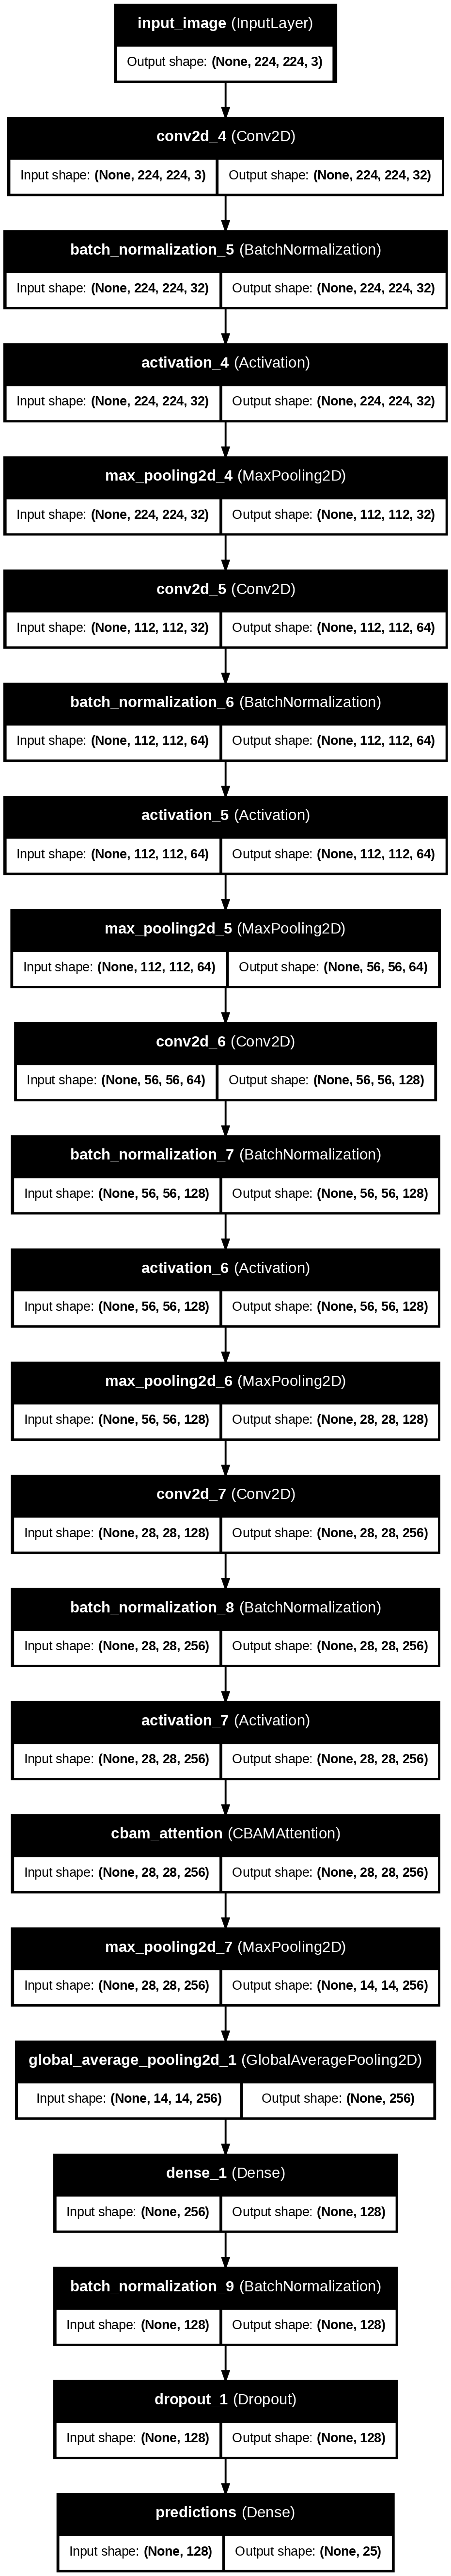

Architecture diagram saved: /kaggle/working/generalized_cnn_cbam_outputs/cnn_cbam_architecture.png


In [100]:
from IPython.display import display, Image as IPythonImage

ATTENTION_OUTPUT_DIR = Path(
    "/kaggle/working/generalized_cnn_cbam_outputs"
)

ATTENTION_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

ATTENTION_ARCHITECTURE_PATH = (
    ATTENTION_OUTPUT_DIR /
    "cnn_cbam_architecture.png"
)

try:
    tf.keras.utils.plot_model(
        attention_model,
        to_file=str(ATTENTION_ARCHITECTURE_PATH),
        show_shapes=True,
        show_layer_names=True,
        expand_nested=False,
        dpi=140
    )

    display(
        IPythonImage(
            filename=str(ATTENTION_ARCHITECTURE_PATH)
        )
    )

    print(
        "Architecture diagram saved:",
        ATTENTION_ARCHITECTURE_PATH
    )

except Exception as error:
    print(
        "Keras architecture image could not be rendered "
        "in this environment."
    )
    print("Reason:", error)
    print(
        "\nText architecture remains available in the "
        "markdown cell above."
    )

### 17.4 Compile and Train the Attention Model

For a fair first comparison, the attention model uses the **same optimizer, initial learning rate, loss, training data, validation data, maximum epochs, early stopping patience, learning-rate scheduler, checkpoint policy, and augmentation pipeline** already used by the baseline.

In [101]:
ATTENTION_BEST_MODEL_PATH = (
    ATTENTION_OUTPUT_DIR /
    "best_generalized_cnn_cbam.keras"
)

ATTENTION_TRAINING_LOG_PATH = (
    ATTENTION_OUTPUT_DIR /
    "training_log_cbam.csv"
)

attention_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=INITIAL_LEARNING_RATE
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

attention_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(ATTENTION_BEST_MODEL_PATH),
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),

    tf.keras.callbacks.CSVLogger(
        filename=str(ATTENTION_TRAINING_LOG_PATH)
    ),

    tf.keras.callbacks.TerminateOnNaN()
]

print("CNN + CBAM compiled.")
print("Attention callbacks configured.")

CNN + CBAM compiled.
Attention callbacks configured.


In [102]:
import time

attention_training_start = time.perf_counter()

attention_history = attention_model.fit(
    train_ds,
    validation_data=internal_val_ds,
    epochs=MAX_EPOCHS,
    callbacks=attention_callbacks,
    verbose=1
)

attention_training_time_seconds = (
    time.perf_counter() -
    attention_training_start
)

print(
    "\nCNN + CBAM training time: "
    f"{attention_training_time_seconds:.2f} seconds "
    f"({attention_training_time_seconds / 60:.2f} minutes)"
)

Epoch 1/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.4605 - loss: 2.0224
Epoch 1: val_loss improved from None to 3.22457, saving model to /kaggle/working/generalized_cnn_cbam_outputs/best_generalized_cnn_cbam.keras

Epoch 1: finished saving model to /kaggle/working/generalized_cnn_cbam_outputs/best_generalized_cnn_cbam.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 60s 230ms/step - accuracy: 0.6105 - loss: 1.5160 - val_accuracy: 0.0868 - val_loss: 3.2246 - learning_rate: 5.0000e-04
Epoch 2/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.8012 - loss: 0.8043
Epoch 2: val_loss improved from 3.22457 to 1.72259, saving model to /kaggle/working/generalized_cnn_cbam_outputs/best_generalized_cnn_cbam.keras

Epoch 2: finished saving model to /kaggle/working/generalized_cnn_cbam_outputs/best_generalized_cnn_cbam.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 43s 195ms/step - accuracy: 0.8113 - loss: 0.7668 - val_accuracy: 0.5517 - val_loss: 1.7226 - learning_rate: 5.0000e-04
Epoch 3/30
219/21

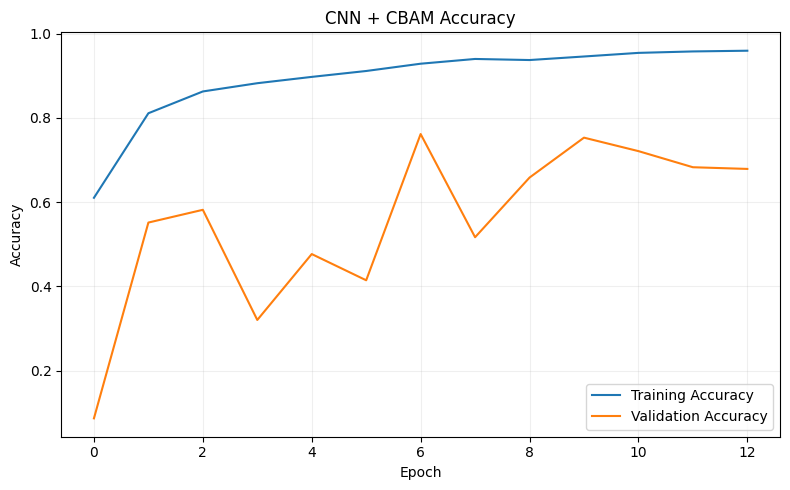

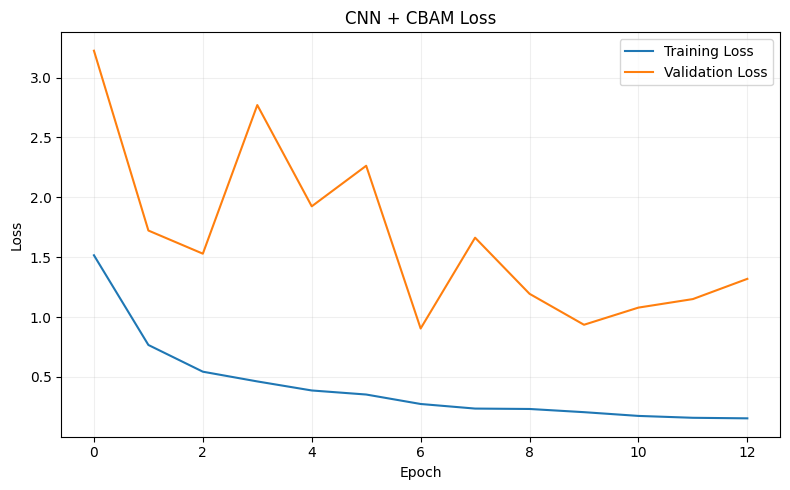

In [103]:
# Training curves for the proposed model

plt.figure(figsize=(8, 5))
plt.plot(
    attention_history.history["accuracy"],
    label="Training Accuracy"
)
plt.plot(
    attention_history.history["val_accuracy"],
    label="Validation Accuracy"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN + CBAM Accuracy")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()

ATTENTION_ACCURACY_CURVE_PATH = (
    ATTENTION_OUTPUT_DIR /
    "cnn_cbam_accuracy_curve.png"
)

plt.savefig(
    ATTENTION_ACCURACY_CURVE_PATH,
    dpi=300,
    bbox_inches="tight"
)
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(
    attention_history.history["loss"],
    label="Training Loss"
)
plt.plot(
    attention_history.history["val_loss"],
    label="Validation Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN + CBAM Loss")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()

ATTENTION_LOSS_CURVE_PATH = (
    ATTENTION_OUTPUT_DIR /
    "cnn_cbam_loss_curve.png"
)

plt.savefig(
    ATTENTION_LOSS_CURVE_PATH,
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### 17.5 Evaluate CNN + CBAM

The proposed model is evaluated on the same internal-validation and untouched test datasets used by the baseline.

In [104]:
best_attention_model = tf.keras.models.load_model(
    ATTENTION_BEST_MODEL_PATH
)

attention_val_loss, attention_val_accuracy = (
    best_attention_model.evaluate(
        internal_val_ds,
        verbose=1
    )
)

attention_test_loss, attention_test_accuracy = (
    best_attention_model.evaluate(
        test_ds,
        verbose=1
    )
)

print(
    f"CBAM Validation Loss     : "
    f"{attention_val_loss:.4f}"
)

print(
    f"CBAM Validation Accuracy : "
    f"{attention_val_accuracy * 100:.2f}%"
)

print(
    f"CBAM Test Loss           : "
    f"{attention_test_loss:.4f}"
)

print(
    f"CBAM Test Accuracy       : "
    f"{attention_test_accuracy * 100:.2f}%"
)

55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - accuracy: 0.7619 - loss: 0.9045
109/109 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.7981 - loss: 0.8150
CBAM Validation Loss     : 0.9045
CBAM Validation Accuracy : 76.19%
CBAM Test Loss           : 0.8150
CBAM Test Accuracy       : 79.81%


In [105]:
attention_y_true = []
attention_y_pred = []
attention_y_prob = []

for images, labels in test_ds:
    probabilities = best_attention_model.predict(
        images,
        verbose=0
    )

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    attention_y_true.extend(
        labels.numpy()
    )

    attention_y_pred.extend(
        predictions
    )

    attention_y_prob.extend(
        probabilities
    )

attention_y_true = np.array(
    attention_y_true
)

attention_y_pred = np.array(
    attention_y_pred
)

attention_y_prob = np.array(
    attention_y_prob
)

print(
    "CNN + CBAM test predictions completed."
)

print(
    "Samples:",
    len(attention_y_true)
)

CNN + CBAM test predictions completed.
Samples: 3477


In [106]:
# Full first-result metric set for the proposed attention model

attention_accuracy = accuracy_score(
    attention_y_true,
    attention_y_pred
)

(
    attention_macro_precision,
    attention_macro_recall,
    attention_macro_f1,
    _
) = precision_recall_fscore_support(
    attention_y_true,
    attention_y_pred,
    average="macro",
    zero_division=0
)

(
    attention_weighted_precision,
    attention_weighted_recall,
    attention_weighted_f1,
    _
) = precision_recall_fscore_support(
    attention_y_true,
    attention_y_pred,
    average="weighted",
    zero_division=0
)

attention_balanced_accuracy = (
    balanced_accuracy_score(
        attention_y_true,
        attention_y_pred
    )
)

attention_kappa = cohen_kappa_score(
    attention_y_true,
    attention_y_pred
)

attention_mcc = matthews_corrcoef(
    attention_y_true,
    attention_y_pred
)

try:
    attention_macro_auc = roc_auc_score(
        attention_y_true,
        attention_y_prob,
        labels=np.arange(NUM_CLASSES),
        multi_class="ovr",
        average="macro"
    )
except ValueError:
    attention_macro_auc = np.nan

print("=" * 55)
print("CNN + CBAM Test Metrics")
print("=" * 55)

print(
    f"Accuracy            : "
    f"{attention_accuracy * 100:.2f}%"
)

print(
    f"Balanced Accuracy   : "
    f"{attention_balanced_accuracy * 100:.2f}%"
)

print(
    f"Macro Precision     : "
    f"{attention_macro_precision * 100:.2f}%"
)

print(
    f"Macro Recall        : "
    f"{attention_macro_recall * 100:.2f}%"
)

print(
    f"Macro F1-score      : "
    f"{attention_macro_f1 * 100:.2f}%"
)

print(
    f"Weighted Precision  : "
    f"{attention_weighted_precision * 100:.2f}%"
)

print(
    f"Weighted Recall     : "
    f"{attention_weighted_recall * 100:.2f}%"
)

print(
    f"Weighted F1-score   : "
    f"{attention_weighted_f1 * 100:.2f}%"
)

print(
    f"Macro ROC-AUC (OvR) : "
    f"{attention_macro_auc:.4f}"
)

print(
    f"Cohen's Kappa       : "
    f"{attention_kappa:.4f}"
)

print(
    f"MCC                 : "
    f"{attention_mcc:.4f}"
)

print("=" * 55)

CNN + CBAM Test Metrics
Accuracy            : 79.81%
Balanced Accuracy   : 77.40%
Macro Precision     : 81.76%
Macro Recall        : 77.40%
Macro F1-score      : 76.77%
Weighted Precision  : 84.87%
Weighted Recall     : 79.81%
Weighted F1-score   : 79.36%
Macro ROC-AUC (OvR) : 0.9819
Cohen's Kappa       : 0.7894
MCC                 : 0.7922


### 17.6 Classification Report

In [107]:
attention_report_text = classification_report(
    attention_y_true,
    attention_y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print(attention_report_text)

attention_report_dict = classification_report(
    attention_y_true,
    attention_y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

attention_report_df = (
    pd.DataFrame(
        attention_report_dict
    )
    .transpose()
)

ATTENTION_REPORT_PATH = (
    ATTENTION_OUTPUT_DIR /
    "classification_report_cbam.csv"
)

attention_report_df.to_csv(
    ATTENTION_REPORT_PATH
)

display(attention_report_df)

print(
    "CBAM classification report saved:",
    ATTENTION_REPORT_PATH
)

              precision    recall  f1-score   support

    Adposhel     0.9172    1.0000    0.9568       144
       Agent     0.4054    0.6250    0.4918       120
     Allaple     0.5165    0.7344    0.6065       128
   Amonetize     0.9140    0.8763    0.8947        97
      Androm     0.9795    0.9533    0.9662       150
     Autorun     0.6853    0.6712    0.6782       146
   BrowseFox     0.6465    0.9720    0.7765       143
      Dinwod     0.9864    0.9732    0.9797       149
        Elex     0.9576    0.7533    0.8433       150
      Expiro     1.0000    0.1258    0.2235       151
      Fasong     0.0000    0.0000    0.0000        33
     HackKMS     1.0000    0.9195    0.9580       149
        Hlux     1.0000    0.9933    0.9967       150
    Injector     0.9545    0.5793    0.7210       145
 InstallCore     0.9660    0.9467    0.9562       150
   MultiPlug     0.9859    0.4698    0.6364       149
  Neoreklami     0.9733    0.9733    0.9733       150
      Neshta     0.3263    

,precision,recall,f1-score,support
Adposhel,0.917197,1.000000,0.956811,144.000000
Agent,0.405405,0.625000,0.491803,120.000000
Allaple,0.516484,0.734375,0.606452,128.000000
Amonetize,0.913978,0.876289,0.894737,97.000000
Androm,0.979452,0.953333,0.966216,150.000000
Autorun,0.685315,0.671233,0.678201,146.000000
BrowseFox,0.646512,0.972028,0.776536,143.000000
Dinwod,0.986395,0.973154,0.979730,149.000000
Elex,0.957627,0.753333,0.843284,150.000000
Expiro,1.000000,0.125828,0.223529,151.000000


CBAM classification report saved: /kaggle/working/generalized_cnn_cbam_outputs/classification_report_cbam.csv


### 17.7 Confusion Matrix

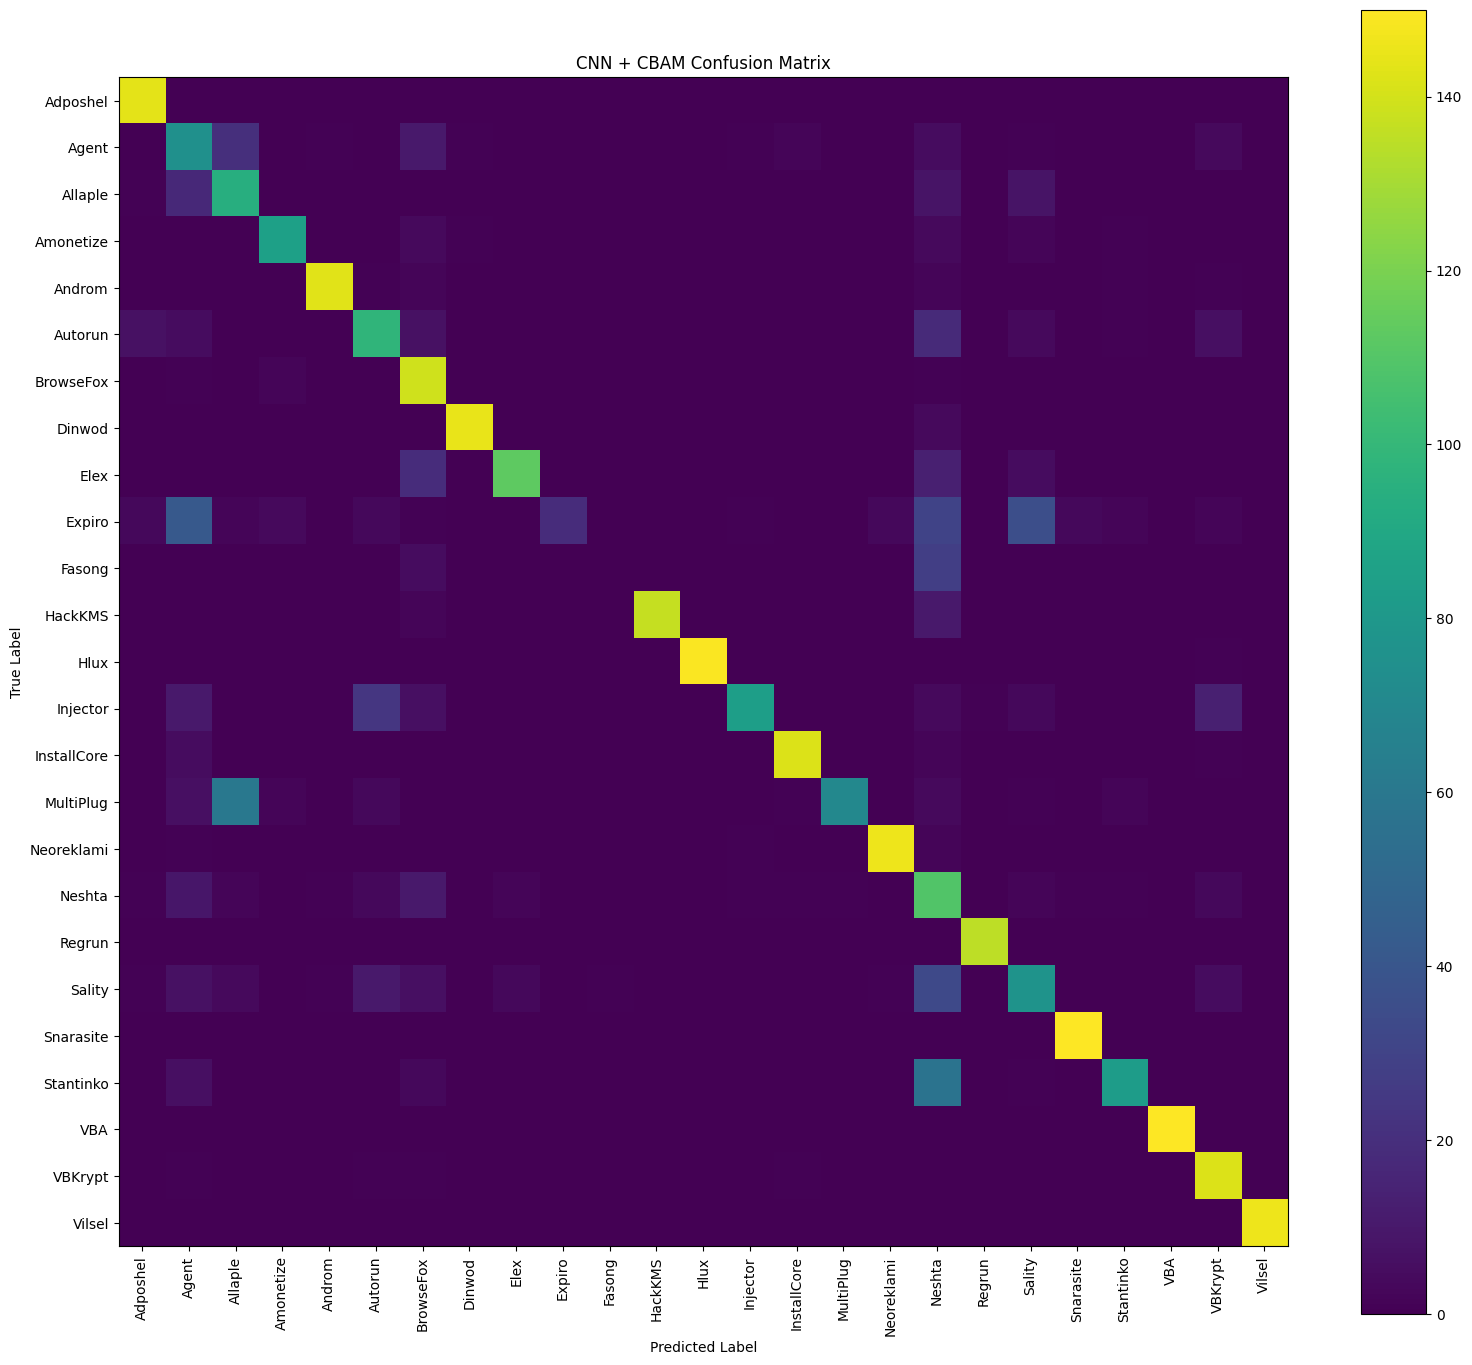

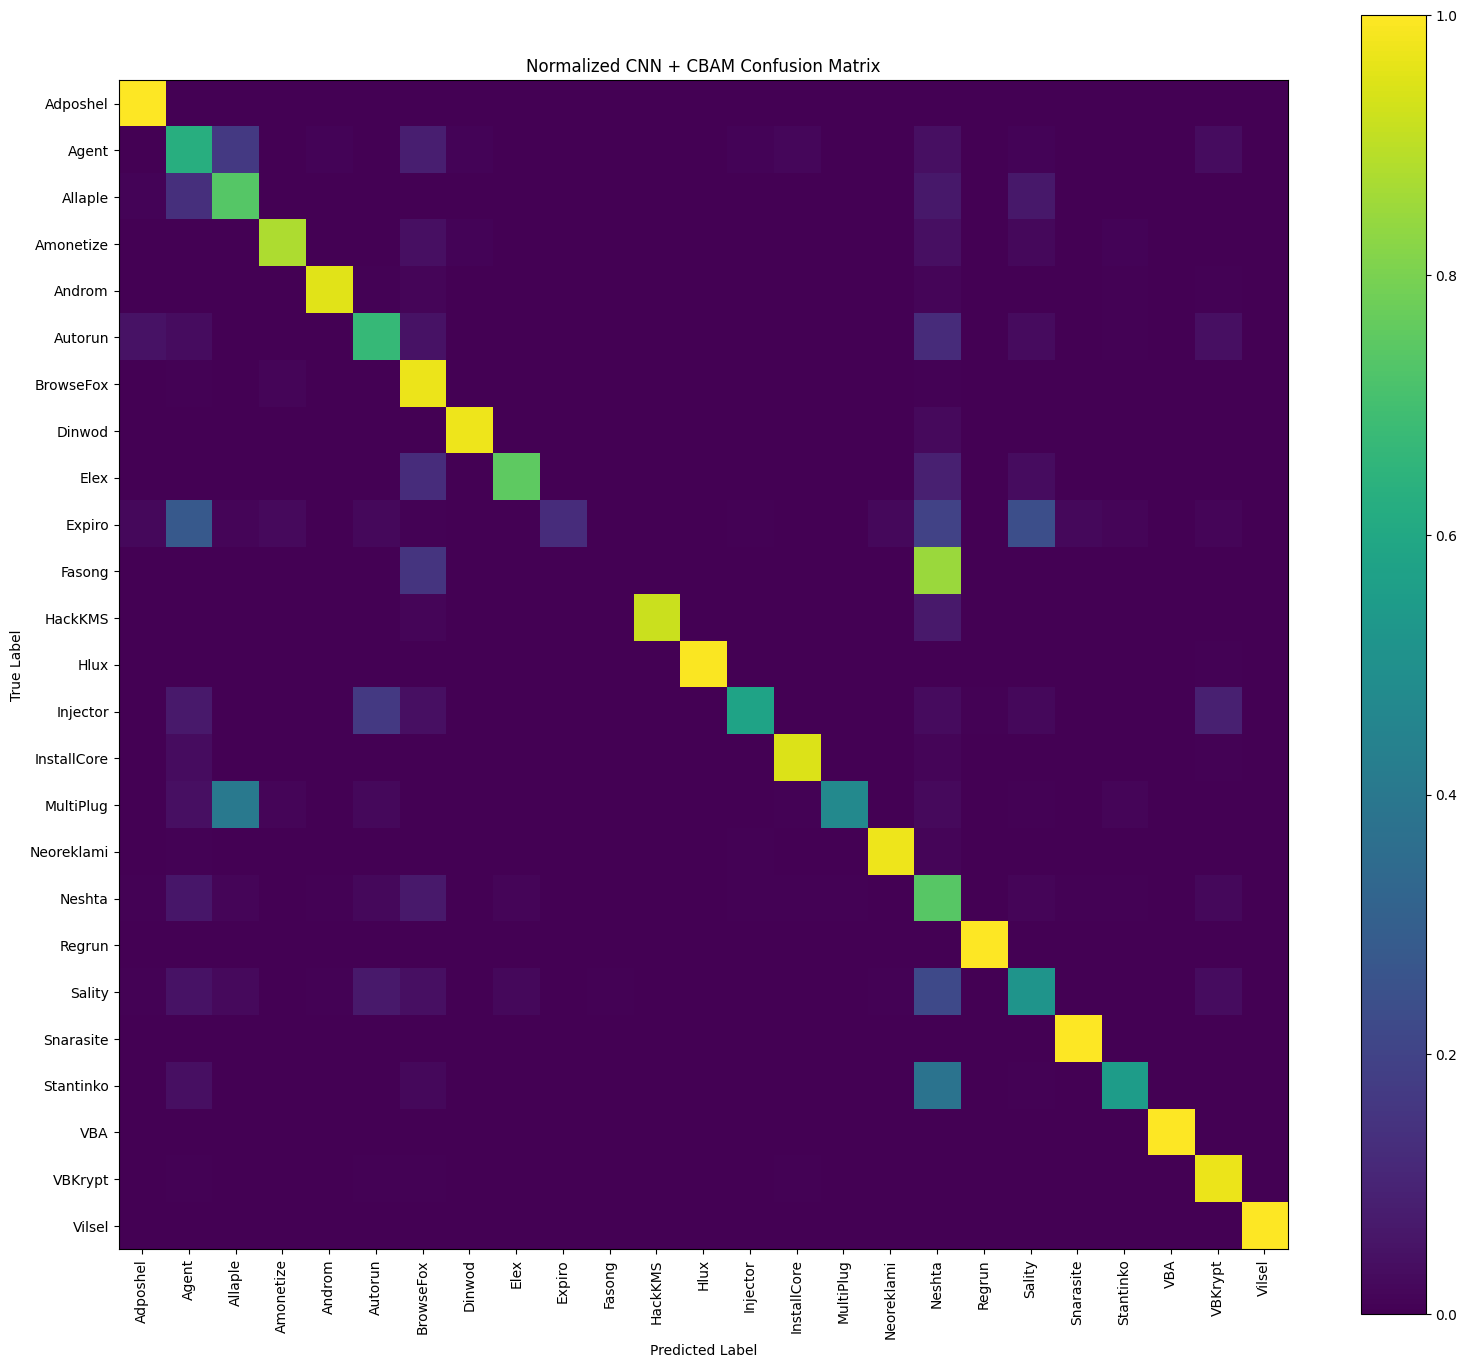

In [108]:
attention_cm = confusion_matrix(
    attention_y_true,
    attention_y_pred
)

plt.figure(figsize=(16, 14))

plt.imshow(
    attention_cm,
    interpolation="nearest"
)

plt.title(
    "CNN + CBAM Confusion Matrix"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

plt.xticks(
    range(NUM_CLASSES),
    class_names,
    rotation=90
)

plt.yticks(
    range(NUM_CLASSES),
    class_names
)

plt.tight_layout()

ATTENTION_CM_PATH = (
    ATTENTION_OUTPUT_DIR /
    "confusion_matrix_cbam.png"
)

plt.savefig(
    ATTENTION_CM_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


attention_cm_normalized = (
    attention_cm.astype("float") /
    np.maximum(
        attention_cm.sum(
            axis=1,
            keepdims=True
        ),
        1
    )
)

plt.figure(figsize=(16, 14))

plt.imshow(
    attention_cm_normalized,
    interpolation="nearest",
    vmin=0,
    vmax=1
)

plt.title(
    "Normalized CNN + CBAM Confusion Matrix"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

plt.xticks(
    range(NUM_CLASSES),
    class_names,
    rotation=90
)

plt.yticks(
    range(NUM_CLASSES),
    class_names
)

plt.tight_layout()

ATTENTION_NORMALIZED_CM_PATH = (
    ATTENTION_OUTPUT_DIR /
    "normalized_confusion_matrix_cbam.png"
)

plt.savefig(
    ATTENTION_NORMALIZED_CM_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 17.8 Training Time, Parameter Count, and Model Size

In [109]:
ATTENTION_FINAL_MODEL_PATH = (
    ATTENTION_OUTPUT_DIR /
    "malevis_generalized_cnn_cbam_final.keras"
)

best_attention_model.save(
    ATTENTION_FINAL_MODEL_PATH
)

attention_parameter_count = (
    best_attention_model.count_params()
)

attention_model_size_mb = (
    ATTENTION_FINAL_MODEL_PATH.stat().st_size /
    (1024 ** 2)
)

attention_complexity_df = pd.DataFrame(
    {
        "Model": [
            "Baseline CNN",
            "CNN + CBAM"
        ],
        "Parameters": [
            baseline_parameter_count,
            attention_parameter_count
        ],
        "Model Size (MB)": [
            baseline_model_size_mb,
            attention_model_size_mb
        ],
        "Training Time (seconds)": [
            BASELINE_TRAINING_TIME_SECONDS_RECORDED,
            attention_training_time_seconds
        ],
        "Training Time Source": [
            "Recorded uploaded baseline run",
            "Measured in this run"
        ]
    }
)

display(attention_complexity_df)

ATTENTION_COMPLEXITY_PATH = (
    ATTENTION_OUTPUT_DIR /
    "baseline_vs_cbam_complexity.csv"
)

attention_complexity_df.to_csv(
    ATTENTION_COMPLEXITY_PATH,
    index=False
)

print(
    "Final CBAM model saved:",
    ATTENTION_FINAL_MODEL_PATH
)

print(
    f"CBAM parameters: "
    f"{attention_parameter_count:,}"
)

print(
    f"CBAM model size: "
    f"{attention_model_size_mb:.2f} MB"
)

print(
    f"CBAM training time: "
    f"{attention_training_time_seconds:.2f} s"
)

,Model,Parameters,Model Size (MB),Training Time (seconds),Training Time Source
0,Baseline CNN,426489,4.962336,553.985202,Recorded uploaded baseline run
1,CNN + CBAM,435051,5.073773,578.043203,Measured in this run


Final CBAM model saved: /kaggle/working/generalized_cnn_cbam_outputs/malevis_generalized_cnn_cbam_final.keras
CBAM parameters: 435,051
CBAM model size: 5.07 MB
CBAM training time: 578.04 s


### 17.9 First Results — Does Attention Help?

The following comparison uses the **same test set** for both models. No result is hard-coded: the conclusion is produced from the actual baseline and CBAM predictions.

In [110]:
comparison_df = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Balanced Accuracy",
            "Macro Precision",
            "Macro Recall",
            "Macro F1",
            "Weighted Precision",
            "Weighted Recall",
            "Weighted F1",
            "Macro ROC-AUC (OvR)",
            "Cohen's Kappa",
            "MCC"
        ],

        "Baseline CNN": [
            baseline_accuracy,
            baseline_balanced_accuracy,
            baseline_macro_precision,
            baseline_macro_recall,
            baseline_macro_f1,
            baseline_weighted_precision,
            baseline_weighted_recall,
            baseline_weighted_f1,
            baseline_macro_auc,
            baseline_kappa,
            baseline_mcc
        ],

        "CNN + CBAM": [
            attention_accuracy,
            attention_balanced_accuracy,
            attention_macro_precision,
            attention_macro_recall,
            attention_macro_f1,
            attention_weighted_precision,
            attention_weighted_recall,
            attention_weighted_f1,
            attention_macro_auc,
            attention_kappa,
            attention_mcc
        ]
    }
)

comparison_df[
    "Difference (CBAM - Baseline)"
] = (
    comparison_df["CNN + CBAM"] -
    comparison_df["Baseline CNN"]
)

display(
    comparison_df.style.format(
        {
            "Baseline CNN": "{:.4f}",
            "CNN + CBAM": "{:.4f}",
            "Difference (CBAM - Baseline)": "{:+.4f}"
        }
    )
)

ATTENTION_COMPARISON_PATH = (
    ATTENTION_OUTPUT_DIR /
    "baseline_vs_cbam_metrics.csv"
)

comparison_df.to_csv(
    ATTENTION_COMPARISON_PATH,
    index=False
)

accuracy_delta = (
    attention_accuracy -
    baseline_accuracy
)

weighted_f1_delta = (
    attention_weighted_f1 -
    baseline_weighted_f1
)

macro_f1_delta = (
    attention_macro_f1 -
    baseline_macro_f1
)

print("\n" + "=" * 65)
print("FIRST RESULT: DOES ATTENTION HELP?")
print("=" * 65)

print(
    f"Accuracy change     : "
    f"{accuracy_delta * 100:+.2f} percentage points"
)

print(
    f"Weighted F1 change  : "
    f"{weighted_f1_delta * 100:+.2f} percentage points"
)

print(
    f"Macro F1 change     : "
    f"{macro_f1_delta * 100:+.2f} percentage points"
)

if weighted_f1_delta > 0 and accuracy_delta > 0:
    print(
        "\nConclusion: YES. In this first controlled experiment, "
        "CBAM improved both test accuracy and weighted F1 over "
        "the unchanged baseline CNN."
    )

elif weighted_f1_delta > 0 or accuracy_delta > 0:
    print(
        "\nConclusion: MIXED. CBAM improved at least one primary "
        "metric, but not both accuracy and weighted F1. "
        "Task 3 tuning and cross-validation are needed before "
        "making a stronger claim."
    )

elif abs(weighted_f1_delta) < 1e-12 and abs(accuracy_delta) < 1e-12:
    print(
        "\nConclusion: NO CLEAR CHANGE. The first CBAM model "
        "matched the baseline on the primary metrics."
    )

else:
    print(
        "\nConclusion: NOT YET. The first CBAM configuration did "
        "not improve the primary test metrics. This is still a "
        "valid Task 2 first result; Task 3 can tune the attention "
        "placement/settings and perform ablation."
    )

print("=" * 65)

print(
    "\nComparison saved:",
    ATTENTION_COMPARISON_PATH
)

,Metric,Baseline CNN,CNN + CBAM,Difference (CBAM - Baseline)
0,Accuracy,0.7725,0.7981,+0.0256
1,Balanced Accuracy,0.7787,0.7740,-0.0047
2,Macro Precision,0.8326,0.8176,-0.0149
3,Macro Recall,0.7787,0.7740,-0.0047
4,Macro F1,0.7730,0.7677,-0.0052
5,Weighted Precision,0.8283,0.8487,+0.0204
6,Weighted Recall,0.7725,0.7981,+0.0256
7,Weighted F1,0.7656,0.7936,+0.0280
8,Macro ROC-AUC (OvR),0.9814,0.9819,+0.0005
9,Cohen's Kappa,0.7627,0.7894,+0.0267



FIRST RESULT: DOES ATTENTION HELP?
Accuracy change     : +2.56 percentage points
Weighted F1 change  : +2.80 percentage points
Macro F1 change     : -0.52 percentage points

Conclusion: YES. In this first controlled experiment, CBAM improved both test accuracy and weighted F1 over the unchanged baseline CNN.

Comparison saved: /kaggle/working/generalized_cnn_cbam_outputs/baseline_vs_cbam_metrics.csv
